In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

  

In [4]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "+featureCounts$", full.names = T)

f_files


[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts"
  [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.1.featureCounts"
  [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.2.featureCounts"
  [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-20.5dpp.3.featureCounts"
 [10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.1.featureCounts"        
 [11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.2.featureCounts"        
 [12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-12.5dpp.3.featureCounts"        
 [13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts"        
 [14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts"        
 [15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts"        
 [16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.1.featureCounts"        
 [17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.2.featureCounts"        
 [18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-20.5dpp.3.featureCounts"        
 [19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts"      
 [20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts"      
 [21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts"      
 [22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts"      
 [23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts"      
 [24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts"      
 [25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts"      
 [26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts"      
 [27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts"      
 [28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.1.featureCounts"    
 [29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-12.5dpp.2.featureCounts"    
 [30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/st

In [5]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [16] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [19] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [22] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
 [25] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
 [28] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [31] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [34] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [37] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
 [40] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
 [43] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
 [46] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [49] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [52] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [55] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [58] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [61] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [64] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
 [67] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
 [70] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [73] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
 [76] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
 [79] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
 [82] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
 [85] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [88] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [91] "LP_J-12.5dpp"        "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [94] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [97] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[100] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[103] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[106] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[109] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"  
[112] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"  
[115] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[118] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[121] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[124] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[127] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[130] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[133] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[136] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[139] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[142] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [6]:
samplenames <- c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','
FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'LP_J-P12.5','LP_J-P12.5','LP_J-P12.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-E16.5',
'LP_J-P20.5','LP_J-P20.5','LP_J-P20.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5',
'NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')
samplenames

[1] "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5"
  [4] "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5"
  [7] "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5"
 [10] "A_J-P12.5"         "A_J-P12.5"         "A_J-P12.5"        
 [13] "A_J-E16.5"         "A_J-E16.5"         "A_J-E16.5"        
 [16] "A_J-P20.5"         "A_J-P20.5"         "A_J-P20.5"        
 [19] "AKR_J-P12.5"       "AKR_J-P12.5"       "AKR_J-P12.5"      
 [22] "AKR_J-E16.5"       "AKR_J-E16.5"       "AKR_J-E16.5"      
 [25] "AKR_J-P20.5"       "AKR_J-P20.5"       "AKR_J-P20.5"      
 [28] "BALB_cJ-P12.5"     "BALB_cJ-P12.5"     "BALB_cJ-P12.5"    
 [31] "BALB_cJ-E16.5"     "BALB_cJ-E16.5"     "BALB_cJ-E16.5"    
 [34] "BALB_cJ-P20.5"     "BALB_cJ-P20.5"     "BALB_cJ-P20.5"    
 [37] "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"    
 [40] "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"    
 [43] "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"    
 [46] "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"  
 [49] "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"  
 [52] "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"  
 [55] "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"   
 [58] "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"   
 [61] "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"   
 [64] "CBA_J-P12.5"       "CBA_J-P12.5"       "CBA_J-P12.5"      
 [67] "CBA_J-E16.5"       "CBA_J-E16.5"       "CBA_J-E16.5"      
 [70] "CBA_J-P20.5"       "CBA_J-P20.5"       "CBA_J-P20.5"      
 [73] "DBA_2J-P12.5"      "DBA_2J-P12.5"      "DBA_2J-P12.5"     
 [76] "DBA_2J-E16.5"      "DBA_2J-E16.5"      "DBA_2J-E16.5"     
 [79] "DBA_2J-P20.5"      "DBA_2J-P20.5"      "DBA_2J-P20.5"     
 [82] "FVB_NJ-P12.5"      "FVB_NJ-P12.5"      "FVB_NJ-P12.5"     
 [85] "FVB_NJ-E16.5"      "FVB_NJ-E16.5"      "FVB_NJ-E16.5"     
 [88] "\nFVB_NJ-P20.5"    "FVB_NJ-P20.5"      "FVB_NJ-P20.5"     
 [91] "LP_J-P12.5"        "LP_J-P12.5"        "LP_J-P12.5"       
 [94] "LP_J-E16.5"        "LP_J-E16.5"        "LP_J-E16.5"       
 [97] "LP_J-P20.5"        "LP_J-P20.5"        "LP_J-P20.5"       
[100] "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5" 
[103] "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5" 
[106] "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5" 
[109] "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"  
[112] "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-E16.5"  
[115] "NZO_HlLtJ-P20.5"   "NZO_HlLtJ-P20.5"   "NZO_HlLtJ-P20.5"  
[118] "PWK_PhJ-P12.5"     "PWK_PhJ-P12.5"     "PWK_PhJ-P12.5"    
[121] "PWK_PhJ-E16.5"     "PWK_PhJ-E16.5"     "PWK_PhJ-E16.5"    
[124] "PWK_PhJ-P20.5"     "PWK_PhJ-P20.5"     "PWK_PhJ-P20.5"    
[127] "SPRET_EiJ-P12.5"   "SPRET_EiJ-P12.5"   "SPRET_EiJ-P12.5"  
[130] "SPRET_EiJ-E16.5"   "SPRET_EiJ-E16.5"   "SPRET_EiJ-E16.5"  
[133] "SPRET_EiJ-P20.5"   "SPRET_EiJ-P20.5"   "SPRET_EiJ-P20.5"  
[136] "WSB_EiJ-P12.5"     "WSB_EiJ-P12.5"     "WSB_EiJ-P12.5"    
[139] "WSB_EiJ-E16.5"     "WSB_EiJ-E16.5"     "WSB_EiJ-E16.5"    
[142] "WSB_EiJ-P20.5"     "WSB_EiJ-P20.5"     "WSB_EiJ-P20.5"

In [7]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [8]:
lables <- c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3',
'129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3',
'129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3',
'A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3',
'A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3',
'A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3',
'AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3',
'AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3',
'BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3',
'BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3',
'C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3',
'C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3',
'C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3',
'C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3',
'CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3',
'CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3',
'CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3',
'CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3',
'DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3',
'DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3',
'FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3',
'FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3',
'LP_J-P12.5.1','LP_J-P12.5.2','LP_J-P12.5.3',
'LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3',
'LP_J-P20.5.1','LP_J-P20.5.2','LP_J-P20.5.3',
'NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3',
'NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3',
'NZO_HlLtJ-P12.5.1','NZO_HlLtJ-P12.5.2','NZO_HlLtJ-P12.5.3',
'NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.2','NZO_HlLtJ-E16.5.3',
'NZO_HlLtJ-P20.5.1','NZO_HlLtJ-P20.5.2','NZO_HlLtJ-P20.5.3',
'PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3',
'PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3',
'SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3',
'SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3',
'WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3',
'WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')
lables 

[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
  [4] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
  [7] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [10] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [13] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [16] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [19] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
 [22] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
 [25] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
 [28] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
 [31] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
 [34] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
 [37] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
 [40] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
 [43] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
 [46] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
 [49] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
 [52] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
 [55] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
 [58] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
 [61] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
 [64] "CBA_J-P12.5.1"       "CBA_J-P12.5.2"       "CBA_J-P12.5.3"      
 [67] "CBA_J-E16.5.1"       "CBA_J-E16.5.2"       "CBA_J-E16.5.3"      
 [70] "CBA_J-P20.5.1"       "CBA_J-P20.5.2"       "CBA_J-P20.5.3"      
 [73] "DBA_2J-P12.5.1"      "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"     
 [76] "DBA_2J-E16.5.1"      "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"     
 [79] "DBA_2J-P20.5.1"      "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"     
 [82] "FVB_NJ-P12.5.1"      "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"     
 [85] "FVB_NJ-E16.5.1"      "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"     
 [88] "FVB_NJ-P20.5.1"      "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"     
 [91] "LP_J-P12.5.1"        "LP_J-P12.5.2"        "LP_J-P12.5.3"       
 [94] "LP_J-E16.5.1"        "LP_J-E16.5.2"        "LP_J-E16.5.3"       
 [97] "LP_J-P20.5.1"        "LP_J-P20.5.2"        "LP_J-P20.5.3"       
[100] "NOD_ShiLtJ-P12.5.1"  "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3" 
[103] "NOD_ShiLtJ-E16.5.1"  "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3" 
[106] "NOD_ShiLtJ-P20.5.1"  "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3" 
[109] "NZO_HlLtJ-P12.5.1"   "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"  
[112] "NZO_HlLtJ-E16.5.1"   "NZO_HlLtJ-E16.5.2"   "NZO_HlLtJ-E16.5.3"  
[115] "NZO_HlLtJ-P20.5.1"   "NZO_HlLtJ-P20.5.2"   "NZO_HlLtJ-P20.5.3"  
[118] "PWK_PhJ-P12.5.1"     "PWK_PhJ-P12.5.2"     "PWK_PhJ-P12.5.3"    
[121] "PWK_PhJ-E16.5.1"     "PWK_PhJ-E16.5.2"     "PWK_PhJ-E16.5.3"    
[124] "PWK_PhJ-P20.5.1"     "PWK_PhJ-P20.5.2"     "PWK_PhJ-P20.5.3"    
[127] "SPRET_EiJ-P12.5.1"   "SPRET_EiJ-P12.5.2"   "SPRET_EiJ-P12.5.3"  
[130] "SPRET_EiJ-E16.5.1"   "SPRET_EiJ-E16.5.2"   "SPRET_EiJ-E16.5.3"  
[133] "SPRET_EiJ-P20.5.1"   "SPRET_EiJ-P20.5.2"   "SPRET_EiJ-P20.5.3"  
[136] "WSB_EiJ-P12.5.1"     "WSB_EiJ-P12.5.2"     "WSB_EiJ-P12.5.3"    
[139] "WSB_EiJ-E16.5.1"     "WSB_EiJ-E16.5.2"     "WSB_EiJ-E16.5.3"    
[142] "WSB_EiJ-P20.5.1"     "WSB_EiJ-P20.5.2"     "WSB_EiJ-P20.5.3"

In [9]:
#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames_order = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5')

In [10]:
#list of sample names with replicates 
#lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))
lables_order = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3',
'BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3',
'A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3',
'FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3',
'C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3',
'129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3',
'DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3',
'AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3',
'CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3',
'NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3',
'WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3',
'CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3',
'PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3',
'SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3')

In [11]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/129S1_SvImJ_v3.5.gff3") #import gff3 file 
A129S1_SvImJ <- na.omit(mcols(A129S1_SvImJ)[,c("gene_id","Name",'type')])
A129S1_SvImJ <- A129S1_SvImJ[A129S1_SvImJ$type == 'gene', ]
A129S1_SvImJ
A129S1_SvImJ_geneName = A129S1_SvImJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A129S1_SvImJ_geneName) <- A129S1_SvImJ_geneName$gene_id
A129S1_SvImJ_geneName$gene_id <- NULL
A129S1_SvImJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.3.featureCounts')
#A129S1_SvImJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
A129S1_SvImJ_samplenames = c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-P20.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5')

A129S1_SvImJ_lables = c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3','129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3','129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3')

A129S1_SvImJ_raw <- readDGE(A129S1_SvImJ_files, columns = c(1, 7), skip = 1, sep="\t", group= A129S1_SvImJ_samplenames, labels = A129S1_SvImJ_lables)

library(dplyr)
A129S1_SvImJ_raw$counts <- merge(x=A129S1_SvImJ_raw$counts, y=A129S1_SvImJ_geneName, by = 0,all.x=TRUE ) #left merge 
A129S1_SvImJ_raw$counts['Row.names'] <- NULL
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts[!is.na(A129S1_SvImJ_raw$counts$Name),] #remove NA 
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A129S1_SvImJ_raw$counts <- as.data.frame(A129S1_SvImJ_raw$counts[!duplicated(A129S1_SvImJ_raw$counts$Name), ])  #remove dulicate values 
rownames(A129S1_SvImJ_raw$counts) <- A129S1_SvImJ_raw$counts$Name #set rawname to gene symbloes 
A129S1_SvImJ_raw$counts$Name <- NULL #remove genesybloe columns 
A129S1_SvImJ_raw

DataFrame with 20396 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00200002305        ugt1a1     gene
2     ENSMUSG00200002142          Xkr4     gene
3     ENSMUSG00200001961           Rp1     gene
4     ENSMUSG00200001998         Sox17     gene
5     ENSMUSG00200002527        Mrpl15     gene
...                  ...           ...      ...
20392 ENSMUSG00200013771         Amelx     gene
20393 ENSMUSG00200013786          Hccs     gene
20394 ENSMUSG00200013810          rbmx     gene
20395 ENSMUSG00200013872          Mid1     gene
20396 ENSMUSG00200013909 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-P12.5,32610006,1
129S1_SvImJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-P12.5,32752175,1
129S1_SvImJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-P12.5,32973035,1
129S1_SvImJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-E16.5,31817792,1
129S1_SvImJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-E16.5,36889870,1
129S1_SvImJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-E16.5,36916967,1
129S1_SvImJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-P20.5,32647842,1
129S1_SvImJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-P20.5,35608819,1
129S1_SvImJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-P20.5,32868857,1


In [12]:
A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/A_J_v3.5.gff3") #import gff3 file 
A_J <- na.omit(mcols(A_J)[,c("gene_id","Name",'type')])
A_J <- A_J[A_J$type == 'gene', ]
A_J
A_J_geneName = A_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A_J_geneName) <- A_J_geneName$gene_id
A_J_geneName$gene_id <- NULL
A_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.3.featureCounts')
#A_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "A_J.+.featureCounts$", full.names = T)
A_J_samplenames = c('A_J-P12.5','A_J-P12.5','A_J-P12.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','A_J-P20.5','A_J-P20.5','A_J-P20.5')

A_J_lables = c('A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3','A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3','A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3')

A_J_raw <- readDGE(A_J_files, columns = c(1, 7), skip = 1, sep="\t", group= A_J_samplenames, labels = A_J_lables)

library(dplyr)
A_J_raw$counts <- merge(x=A_J_raw$counts, y=A_J_geneName, by = 0,all.x=TRUE ) #left merge 
A_J_raw$counts['Row.names'] <- NULL
A_J_raw$counts <- A_J_raw$counts[!is.na(A_J_raw$counts$Name),] #remove NA 
A_J_raw$counts <- A_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A_J_raw$counts <- as.data.frame(A_J_raw$counts[!duplicated(A_J_raw$counts$Name), ])  #remove dulicate values 
rownames(A_J_raw$counts) <- A_J_raw$counts$Name #set rawname to gene symbloes 
A_J_raw$counts$Name <- NULL #remove genesybloe columns 
A_J_raw

DataFrame with 20472 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00195002697          Xkr4     gene
2     ENSMUSG00195002553           Rp1     gene
3     ENSMUSG00195002578         Sox17     gene
4     ENSMUSG00195002659        Mrpl15     gene
5     ENSMUSG00195002525        Lypla1     gene
...                  ...           ...      ...
20468 ENSMUSG00195016023         Amelx     gene
20469 ENSMUSG00195016042          Hccs     gene
20470 ENSMUSG00195016074          rbmx     gene
20471 ENSMUSG00195015519          Mid1     gene
20472 ENSMUSG00195015611 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.1.featureCounts,A_J-P12.5,30120203,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.2.featureCounts,A_J-P12.5,34386447,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-12.5dpp.3.featureCounts,A_J-P12.5,32240297,1
A_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.1.featureCounts,A_J-E16.5,35246275,1
A_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.2.featureCounts,A_J-E16.5,34330130,1
A_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-16.5dpc.3.featureCounts,A_J-E16.5,31912638,1
A_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.1.featureCounts,A_J-P20.5,32023290,1
A_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.2.featureCounts,A_J-P20.5,30950106,1
A_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/A_J-20.5dpp.3.featureCounts,A_J-P20.5,28862943,1


In [13]:
AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/AKR_J_v3.5.gff3") #import gff3 file 
AKR_J <- na.omit(mcols(AKR_J)[,c("gene_id","Name",'type')])
AKR_J <- AKR_J[AKR_J$type == 'gene', ]
AKR_J
AKR_J_geneName = AKR_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(AKR_J_geneName) <- AKR_J_geneName$gene_id
AKR_J_geneName$gene_id <- NULL
AKR_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.3.featureCounts')
#AKR_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
AKR_J_samplenames = c('AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5','AKR_J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5')

AKR_J_lables = c('AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3','AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3')

AKR_J_raw <- readDGE(AKR_J_files, columns = c(1, 7), skip = 1, sep="\t", group= AKR_J_samplenames, labels = AKR_J_lables)
AKR_J_raw
library(dplyr)
AKR_J_raw$counts <- merge(x=AKR_J_raw$counts, y=AKR_J_geneName, by = 0,all.x=TRUE ) #left merge 
AKR_J_raw$counts['Row.names'] <- NULL
AKR_J_raw$counts <- AKR_J_raw$counts[!is.na(AKR_J_raw$counts$Name),] #remove NA 
AKR_J_raw$counts <- AKR_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

AKR_J_raw$counts <- as.data.frame(AKR_J_raw$counts[!duplicated(AKR_J_raw$counts$Name), ])  #remove dulicate values 
rownames(AKR_J_raw$counts) <- AKR_J_raw$counts$Name #set rawname to gene symbloes 
AKR_J_raw$counts$Name <- NULL #remove genesybloe columns 
AKR_J_raw

DataFrame with 20391 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00220003361          Xkr4     gene
2     ENSMUSG00220003474           Rp1     gene
3     ENSMUSG00220003489         Sox17     gene
4     ENSMUSG00220003074        Mrpl15     gene
5     ENSMUSG00220003096        Lypla1     gene
...                  ...           ...      ...
20387 ENSMUSG00220030338         Amelx     gene
20388 ENSMUSG00220030408          Hccs     gene
20389 ENSMUSG00220030465          rbmx     gene
20390 ENSMUSG00220010896          Mid1     gene
20391 ENSMUSG00220010941 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,32612943,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,33459709,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,35377708,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.1.featureCounts,AKR_J-E16.5,30775896,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.2.featureCounts,AKR_J-E16.5,34472536,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.3.featureCounts,AKR_J-E16.5,34977957,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.1.featureCounts,AKR_J-P20.5,34757381,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.2.featureCounts,AKR_J-P20.5,34116675,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.3.featureCounts,AKR_J-P20.5,29994924,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.1.featureCounts,AKR_J-P12.5,32612943,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.2.featureCounts,AKR_J-P12.5,33459709,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-12.5dpp.3.featureCounts,AKR_J-P12.5,35377708,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.1.featureCounts,AKR_J-E16.5,30775896,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.2.featureCounts,AKR_J-E16.5,34472536,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-16.5dpc.3.featureCounts,AKR_J-E16.5,34977957,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.1.featureCounts,AKR_J-P20.5,34757381,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.2.featureCounts,AKR_J-P20.5,34116675,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/AKR_J-20.5dpp.3.featureCounts,AKR_J-P20.5,29994924,1


In [14]:
BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/BALB_cJ_v3.5.gff3") #import gff3 file 
BALB_cJ <- na.omit(mcols(BALB_cJ)[,c("gene_id","Name",'type')])
BALB_cJ <- BALB_cJ[BALB_cJ$type == 'gene', ]
BALB_cJ
BALB_cJ_geneName = BALB_cJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(BALB_cJ_geneName) <- BALB_cJ_geneName$gene_id
BALB_cJ_geneName$gene_id <- NULL
BALB_cJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.3.featureCounts')
#BALB_cJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
BALB_cJ_samplenames = c('BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-E16.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5')

BALB_cJ_lables = c('BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3','BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3')

BALB_cJ_raw <- readDGE(BALB_cJ_files, columns = c(1, 7), skip = 1, sep="\t", group= BALB_cJ_samplenames, labels = BALB_cJ_lables)
BALB_cJ_raw
library(dplyr)
BALB_cJ_raw$counts <- merge(x=BALB_cJ_raw$counts, y=BALB_cJ_geneName, by = 0,all.x=TRUE ) #left merge 
BALB_cJ_raw$counts['Row.names'] <- NULL
BALB_cJ_raw$counts <- BALB_cJ_raw$counts[!is.na(BALB_cJ_raw$counts$Name),] #remove NA 
BALB_cJ_raw$counts <- BALB_cJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

BALB_cJ_raw$counts <- as.data.frame(BALB_cJ_raw$counts[!duplicated(BALB_cJ_raw$counts$Name), ])  #remove dulicate values 
rownames(BALB_cJ_raw$counts) <- BALB_cJ_raw$counts$Name #set rawname to gene symbloes 
BALB_cJ_raw$counts$Name <- NULL #remove genesybloe columns 
BALB_cJ_raw

DataFrame with 20490 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00180008421          Xkr4     gene
2     ENSMUSG00180008881           Rp1     gene
3     ENSMUSG00180008896         Sox17     gene
4     ENSMUSG00180008861        Mrpl15     gene
5     ENSMUSG00180008716        Lypla1     gene
...                  ...           ...      ...
20486 ENSMUSG00180017230          Mid1     gene
20487 ENSMUSG00180017318 4933400A11Rik     gene
20488 ENSMUSG00180017370         HSPB7     gene
20489 ENSMUSG00180017573           GSN     gene
20490 ENSMUSG00180017649          Asmt     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.1.featureCounts,BALB_cJ-P12.5,30071794,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.2.featureCounts,BALB_cJ-P12.5,30958956,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.3.featureCounts,BALB_cJ-P12.5,31962760,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.1.featureCounts,BALB_cJ-E16.5,35222432,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.2.featureCounts,BALB_cJ-E16.5,31518164,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.3.featureCounts,BALB_cJ-E16.5,38053146,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.1.featureCounts,BALB_cJ-P20.5,30404956,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.2.featureCounts,BALB_cJ-P20.5,32168990,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.3.featureCounts,BALB_cJ-P20.5,32845232,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.1.featureCounts,BALB_cJ-P12.5,30071794,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.2.featureCounts,BALB_cJ-P12.5,30958956,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-12.5dpp.3.featureCounts,BALB_cJ-P12.5,31962760,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.1.featureCounts,BALB_cJ-E16.5,35222432,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.2.featureCounts,BALB_cJ-E16.5,31518164,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-16.5dpc.3.featureCounts,BALB_cJ-E16.5,38053146,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.1.featureCounts,BALB_cJ-P20.5,30404956,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.2.featureCounts,BALB_cJ-P20.5,32168990,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/BALB_cJ-20.5dpp.3.featureCounts,BALB_cJ-P20.5,32845232,1


In [15]:
C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/C3H_HeJ_v3.5.gff3") #import gff3 file 
C3H_HeJ <- na.omit(mcols(C3H_HeJ)[,c("gene_id","Name",'type')])
C3H_HeJ <- C3H_HeJ[C3H_HeJ$type == 'gene', ]
C3H_HeJ
C3H_HeJ_geneName = C3H_HeJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C3H_HeJ_geneName) <- C3H_HeJ_geneName$gene_id
C3H_HeJ_geneName$gene_id <- NULL
C3H_HeJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.3.featureCounts')
#C3H_HeJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C3H_HeJ_samplenames = c('C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-E16.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5')

C3H_HeJ_lables = c('C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3','C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3')

C3H_HeJ_raw <- readDGE(C3H_HeJ_files, columns = c(1, 7), skip = 1, sep="\t", group= C3H_HeJ_samplenames, labels = C3H_HeJ_lables)
C3H_HeJ_raw
library(dplyr)
C3H_HeJ_raw$counts <- merge(x=C3H_HeJ_raw$counts, y=C3H_HeJ_geneName, by = 0,all.x=TRUE ) #left merge 
C3H_HeJ_raw$counts['Row.names'] <- NULL
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts[!is.na(C3H_HeJ_raw$counts$Name),] #remove NA 
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C3H_HeJ_raw$counts <- as.data.frame(C3H_HeJ_raw$counts[!duplicated(C3H_HeJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C3H_HeJ_raw$counts) <- C3H_HeJ_raw$counts$Name #set rawname to gene symbloes 
C3H_HeJ_raw$counts$Name <- NULL #remove genesybloe columns 
C3H_HeJ_raw

DataFrame with 20427 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00175000235        CDCA7L     gene
2     ENSMUSG00175000248          Xkr4     gene
3     ENSMUSG00175000083           Rp1     gene
4     ENSMUSG00175000092         Sox17     gene
5     ENSMUSG00175000224        Mrpl15     gene
...                  ...           ...      ...
20423 ENSMUSG00175010162          Hccs     gene
20424 ENSMUSG00175010173          rbmx     gene
20425 ENSMUSG00175010317          Mid1     gene
20426 ENSMUSG00175010348 4933400A11Rik     gene
20427 ENSMUSG00175010363       DYNLRB2     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.1.featureCounts,C3H_HeJ-P12.5,31142367,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.2.featureCounts,C3H_HeJ-P12.5,30794144,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.3.featureCounts,C3H_HeJ-P12.5,34950572,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.1.featureCounts,C3H_HeJ-E16.5,32969727,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.2.featureCounts,C3H_HeJ-E16.5,34917800,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.3.featureCounts,C3H_HeJ-E16.5,31924393,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.1.featureCounts,C3H_HeJ-P20.5,30760337,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.2.featureCounts,C3H_HeJ-P20.5,31735818,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.3.featureCounts,C3H_HeJ-P20.5,29457530,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.1.featureCounts,C3H_HeJ-P12.5,31142367,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.2.featureCounts,C3H_HeJ-P12.5,30794144,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-12.5dpp.3.featureCounts,C3H_HeJ-P12.5,34950572,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.1.featureCounts,C3H_HeJ-E16.5,32969727,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.2.featureCounts,C3H_HeJ-E16.5,34917800,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-16.5dpc.3.featureCounts,C3H_HeJ-E16.5,31924393,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.1.featureCounts,C3H_HeJ-P20.5,30760337,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.2.featureCounts,C3H_HeJ-P20.5,31735818,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C3H_HeJ-20.5dpp.3.featureCounts,C3H_HeJ-P20.5,29457530,1


In [16]:
C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/C57BL_6NJ_v3.5.gff3") #import gff3 file 
C57BL_6NJ <- na.omit(mcols(C57BL_6NJ)[,c("gene_id","Name",'type')])
C57BL_6NJ <- C57BL_6NJ[C57BL_6NJ$type == 'gene', ]
C57BL_6NJ
C57BL_6NJ_geneName = C57BL_6NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C57BL_6NJ_geneName) <- C57BL_6NJ_geneName$gene_id
C57BL_6NJ_geneName$gene_id <- NULL
C57BL_6NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.3.featureCounts')
#C57BL_6NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C57BL_6NJ_samplenames = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5')

C57BL_6NJ_lables = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3','C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3')

C57BL_6NJ_raw <- readDGE(C57BL_6NJ_files, columns = c(1, 7), skip = 1, sep="\t", group= C57BL_6NJ_samplenames, labels = C57BL_6NJ_lables)
C57BL_6NJ_raw
library(dplyr)
C57BL_6NJ_raw$counts <- merge(x=C57BL_6NJ_raw$counts, y=C57BL_6NJ_geneName, by = 0,all.x=TRUE ) #left merge 
C57BL_6NJ_raw$counts['Row.names'] <- NULL
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts[!is.na(C57BL_6NJ_raw$counts$Name),] #remove NA 
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C57BL_6NJ_raw$counts <- as.data.frame(C57BL_6NJ_raw$counts[!duplicated(C57BL_6NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C57BL_6NJ_raw$counts) <- C57BL_6NJ_raw$counts$Name #set rawname to gene symbloes 
C57BL_6NJ_raw$counts$Name <- NULL #remove genesybloe columns 
C57BL_6NJ_raw

DataFrame with 20459 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00215003924          Xkr4     gene
2     ENSMUSG00215004064           Rp1     gene
3     ENSMUSG00215004070         Sox17     gene
4     ENSMUSG00215004045        Mrpl15     gene
5     ENSMUSG00215004089        Lypla1     gene
...                  ...           ...      ...
20455 ENSMUSG00215015868         Amelx     gene
20456 ENSMUSG00215016025          Hccs     gene
20457 ENSMUSG00215016164          rbmx     gene
20458 ENSMUSG00215016408          Mid1     gene
20459 ENSMUSG00215016857 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.1.featureCounts,C57BL_6NJ-P12.5,36420614,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.2.featureCounts,C57BL_6NJ-P12.5,30575698,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.3.featureCounts,C57BL_6NJ-P12.5,36537790,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.1.featureCounts,C57BL_6NJ-E16.5,36235489,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.2.featureCounts,C57BL_6NJ-E16.5,35583705,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.3.featureCounts,C57BL_6NJ-E16.5,36132442,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.1.featureCounts,C57BL_6NJ-P20.5,31779551,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.2.featureCounts,C57BL_6NJ-P20.5,34134483,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.3.featureCounts,C57BL_6NJ-P20.5,32755964,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.1.featureCounts,C57BL_6NJ-P12.5,36420614,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.2.featureCounts,C57BL_6NJ-P12.5,30575698,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-12.5dpp.3.featureCounts,C57BL_6NJ-P12.5,36537790,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.1.featureCounts,C57BL_6NJ-E16.5,36235489,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.2.featureCounts,C57BL_6NJ-E16.5,35583705,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-16.5dpc.3.featureCounts,C57BL_6NJ-E16.5,36132442,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.1.featureCounts,C57BL_6NJ-P20.5,31779551,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.2.featureCounts,C57BL_6NJ-P20.5,34134483,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/C57BL_6NJ-20.5dpp.3.featureCounts,C57BL_6NJ-P20.5,32755964,1


In [17]:
CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/CAST_EiJ_v3.5.gff3") #import gff3 file 
CAST_EiJ <- na.omit(mcols(CAST_EiJ)[,c("gene_id","Name",'type')])
CAST_EiJ <- CAST_EiJ[CAST_EiJ$type == 'gene', ]
CAST_EiJ
CAST_EiJ_geneName = CAST_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CAST_EiJ_geneName) <- CAST_EiJ_geneName$gene_id
CAST_EiJ_geneName$gene_id <- NULL
CAST_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.3.featureCounts')
#CAST_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CAST_EiJ_samplenames = c('CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-E16.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5')

CAST_EiJ_lables = c('CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3','CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3')

CAST_EiJ_raw <- readDGE(CAST_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= CAST_EiJ_samplenames, labels = CAST_EiJ_lables)
CAST_EiJ_raw
library(dplyr)
CAST_EiJ_raw$counts <- merge(x=CAST_EiJ_raw$counts, y=CAST_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
CAST_EiJ_raw$counts['Row.names'] <- NULL
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts[!is.na(CAST_EiJ_raw$counts$Name),] #remove NA 
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CAST_EiJ_raw$counts <- as.data.frame(CAST_EiJ_raw$counts[!duplicated(CAST_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(CAST_EiJ_raw$counts) <- CAST_EiJ_raw$counts$Name #set rawname to gene symbloes 
CAST_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
CAST_EiJ_raw

DataFrame with 20368 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSTCUG00005001819        MROH2A     gene
2     ENSTCUG00005001868         HJURP     gene
3     ENSTCUG00005002045          Xkr4     gene
4     ENSTCUG00005001875           Rp1     gene
5     ENSTCUG00005001952         Sox17     gene
...                  ...           ...      ...
20364 ENSTCUG00005024214          Hccs     gene
20365 ENSTCUG00005024248          rbmx     gene
20366 ENSTCUG00005023838          PRC1     gene
20367 ENSTCUG00005024102          MID1     gene
20368 ENSTCUG00005024201 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.1.featureCounts,CAST_EiJ-P12.5,31219658,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.2.featureCounts,CAST_EiJ-P12.5,34922286,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.3.featureCounts,CAST_EiJ-P12.5,31609156,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.1.featureCounts,CAST_EiJ-E16.5,32743776,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.2.featureCounts,CAST_EiJ-E16.5,31982083,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.3.featureCounts,CAST_EiJ-E16.5,31055572,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.1.featureCounts,CAST_EiJ-P20.5,30303659,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.2.featureCounts,CAST_EiJ-P20.5,30060404,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.3.featureCounts,CAST_EiJ-P20.5,31039147,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.1.featureCounts,CAST_EiJ-P12.5,31219658,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.2.featureCounts,CAST_EiJ-P12.5,34922286,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-12.5dpp.3.featureCounts,CAST_EiJ-P12.5,31609156,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.1.featureCounts,CAST_EiJ-E16.5,32743776,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.2.featureCounts,CAST_EiJ-E16.5,31982083,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-16.5dpc.3.featureCounts,CAST_EiJ-E16.5,31055572,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.1.featureCounts,CAST_EiJ-P20.5,30303659,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.2.featureCounts,CAST_EiJ-P20.5,30060404,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CAST_EiJ-20.5dpp.3.featureCounts,CAST_EiJ-P20.5,31039147,1


In [18]:
CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/CBA_J_v3.5.gff3") #import gff3 file 
CBA_J <- na.omit(mcols(CBA_J)[,c("gene_id","Name",'type')])
CBA_J <- CBA_J[CBA_J$type == 'gene', ]
CBA_J
CBA_J_geneName = CBA_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CBA_J_geneName) <- CBA_J_geneName$gene_id
CBA_J_geneName$gene_id <- NULL
CBA_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.3.featureCounts')
#CBA_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CBA_J_samplenames = c('CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5','CBA_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5')

CBA_J_lables = c('CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3','CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3')

CBA_J_raw <- readDGE(CBA_J_files, columns = c(1, 7), skip = 1, sep="\t", group= CBA_J_samplenames, labels = CBA_J_lables)
CBA_J_raw
library(dplyr)
CBA_J_raw$counts <- merge(x=CBA_J_raw$counts, y=CBA_J_geneName, by = 0,all.x=TRUE ) #left merge 
CBA_J_raw$counts['Row.names'] <- NULL
CBA_J_raw$counts <- CBA_J_raw$counts[!is.na(CBA_J_raw$counts$Name),] #remove NA 
CBA_J_raw$counts <- CBA_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CBA_J_raw$counts <- as.data.frame(CBA_J_raw$counts[!duplicated(CBA_J_raw$counts$Name), ])  #remove dulicate values 
rownames(CBA_J_raw$counts) <- CBA_J_raw$counts$Name #set rawname to gene symbloes 
CBA_J_raw$counts$Name <- NULL #remove genesybloe columns 
CBA_J_raw

DataFrame with 20435 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00210001546          Xkr4     gene
2     ENSMUSG00210001575           Rp1     gene
3     ENSMUSG00210001604         Sox17     gene
4     ENSMUSG00210001755        Mrpl15     gene
5     ENSMUSG00210001766        Lypla1     gene
...                  ...           ...      ...
20431 ENSMUSG00210028259         Amelx     gene
20432 ENSMUSG00210028307          Hccs     gene
20433 ENSMUSG00210028366          rbmx     gene
20434 ENSMUSG00210027771          Mid1     gene
20435 ENSMUSG00210027942 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CBA_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.1.featureCounts,CBA_J-P12.5,31890290,1
CBA_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.2.featureCounts,CBA_J-P12.5,5019027,1
CBA_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.3.featureCounts,CBA_J-P12.5,31769126,1
CBA_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.1.featureCounts,CBA_J-E16.5,35423626,1
CBA_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.2.featureCounts,CBA_J-E16.5,36034636,1
CBA_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.3.featureCounts,CBA_J-E16.5,37543464,1
CBA_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.1.featureCounts,CBA_J-P20.5,35869372,1
CBA_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.2.featureCounts,CBA_J-P20.5,32195305,1
CBA_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.3.featureCounts,CBA_J-P20.5,32791386,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CBA_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.1.featureCounts,CBA_J-P12.5,31890290,1
CBA_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.2.featureCounts,CBA_J-P12.5,5019027,1
CBA_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-12.5dpp.3.featureCounts,CBA_J-P12.5,31769126,1
CBA_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.1.featureCounts,CBA_J-E16.5,35423626,1
CBA_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.2.featureCounts,CBA_J-E16.5,36034636,1
CBA_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-16.5dpc.3.featureCounts,CBA_J-E16.5,37543464,1
CBA_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.1.featureCounts,CBA_J-P20.5,35869372,1
CBA_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.2.featureCounts,CBA_J-P20.5,32195305,1
CBA_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/CBA_J-20.5dpp.3.featureCounts,CBA_J-P20.5,32791386,1


In [19]:
DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/DBA_2J_v3.5.gff3") #import gff3 file 
DBA_2J <- na.omit(mcols(DBA_2J)[,c("gene_id","Name",'type')])
DBA_2J <- DBA_2J[DBA_2J$type == 'gene', ]
DBA_2J
DBA_2J_geneName = DBA_2J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(DBA_2J_geneName) <- DBA_2J_geneName$gene_id
DBA_2J_geneName$gene_id <- NULL
DBA_2J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.3.featureCounts')
#DBA_2J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
DBA_2J_samplenames = c('DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-E16.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5')

DBA_2J_lables = c('DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3','DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3')

DBA_2J_raw <- readDGE(DBA_2J_files, columns = c(1, 7), skip = 1, sep="\t", group= DBA_2J_samplenames, labels = DBA_2J_lables)
DBA_2J_raw
library(dplyr)
DBA_2J_raw$counts <- merge(x=DBA_2J_raw$counts, y=DBA_2J_geneName, by = 0,all.x=TRUE ) #left merge 
DBA_2J_raw$counts['Row.names'] <- NULL
DBA_2J_raw$counts <- DBA_2J_raw$counts[!is.na(DBA_2J_raw$counts$Name),] #remove NA 
DBA_2J_raw$counts <- DBA_2J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

DBA_2J_raw$counts <- as.data.frame(DBA_2J_raw$counts[!duplicated(DBA_2J_raw$counts$Name), ])  #remove dulicate values 
rownames(DBA_2J_raw$counts) <- DBA_2J_raw$counts$Name #set rawname to gene symbloes 
DBA_2J_raw$counts$Name <- NULL #remove genesybloe columns 
DBA_2J_raw

DataFrame with 20744 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00185003942        ugt1a1     gene
2     ENSMUSG00185003991         HJURP     gene
3     ENSMUSG00185003999         HJURP     gene
4     ENSMUSG00185004005        ugt1a1     gene
5     ENSMUSG00185004011        MROH2A     gene
...                  ...           ...      ...
20740 ENSMUSG00185029791         Amelx     gene
20741 ENSMUSG00185029830          Hccs     gene
20742 ENSMUSG00185029875          rbmx     gene
20743 ENSMUSG00185029083          Mid1     gene
20744 ENSMUSG00185029146 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.1.featureCounts,DBA_2J-P12.5,31244418,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.2.featureCounts,DBA_2J-P12.5,31681951,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.3.featureCounts,DBA_2J-P12.5,31891779,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.1.featureCounts,DBA_2J-E16.5,31828070,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.2.featureCounts,DBA_2J-E16.5,30278159,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.3.featureCounts,DBA_2J-E16.5,29966591,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.1.featureCounts,DBA_2J-P20.5,32277459,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.2.featureCounts,DBA_2J-P20.5,31787357,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.3.featureCounts,DBA_2J-P20.5,33458221,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.1.featureCounts,DBA_2J-P12.5,31244418,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.2.featureCounts,DBA_2J-P12.5,31681951,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-12.5dpp.3.featureCounts,DBA_2J-P12.5,31891779,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.1.featureCounts,DBA_2J-E16.5,31828070,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.2.featureCounts,DBA_2J-E16.5,30278159,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-16.5dpc.3.featureCounts,DBA_2J-E16.5,29966591,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.1.featureCounts,DBA_2J-P20.5,32277459,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.2.featureCounts,DBA_2J-P20.5,31787357,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/DBA_2J-20.5dpp.3.featureCounts,DBA_2J-P20.5,33458221,1


In [20]:
FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/FVB_NJ_v3.5.gff3") #import gff3 file 
FVB_NJ <- na.omit(mcols(FVB_NJ)[,c("gene_id","Name",'type')])
FVB_NJ <- FVB_NJ[FVB_NJ$type == 'gene', ]
FVB_NJ
FVB_NJ_geneName = FVB_NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(FVB_NJ_geneName) <- FVB_NJ_geneName$gene_id
FVB_NJ_geneName$gene_id <- NULL
FVB_NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.3.featureCounts')
#FVB_NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
FVB_NJ_samplenames = c('FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-E16.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5')

FVB_NJ_lables = c('FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3','FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3')

FVB_NJ_raw <- readDGE(FVB_NJ_files, columns = c(1, 7), skip = 1, sep="\t", group= FVB_NJ_samplenames, labels = FVB_NJ_lables)
FVB_NJ_raw
library(dplyr)
FVB_NJ_raw$counts <- merge(x=FVB_NJ_raw$counts, y=FVB_NJ_geneName, by = 0,all.x=TRUE ) #left merge 
FVB_NJ_raw$counts['Row.names'] <- NULL
FVB_NJ_raw$counts <- FVB_NJ_raw$counts[!is.na(FVB_NJ_raw$counts$Name),] #remove NA 
FVB_NJ_raw$counts <- FVB_NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

FVB_NJ_raw$counts <- as.data.frame(FVB_NJ_raw$counts[!duplicated(FVB_NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(FVB_NJ_raw$counts) <- FVB_NJ_raw$counts$Name #set rawname to gene symbloes 
FVB_NJ_raw$counts$Name <- NULL #remove genesybloe columns 
FVB_NJ_raw

DataFrame with 20249 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00205004560          Xkr4     gene
2     ENSMUSG00205004861           Rp1     gene
3     ENSMUSG00205005121         Sox17     gene
4     ENSMUSG00205004846        Mrpl15     gene
5     ENSMUSG00205004466        Lypla1     gene
...                  ...           ...      ...
20245 ENSMUSG00205002553         Amelx     gene
20246 ENSMUSG00205002563          Hccs     gene
20247 ENSMUSG00205002570          rbmx     gene
20248 ENSMUSG00205002644          Mid1     gene
20249 ENSMUSG00205002674 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.1.featureCounts,FVB_NJ-P12.5,28969790,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.2.featureCounts,FVB_NJ-P12.5,37366544,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.3.featureCounts,FVB_NJ-P12.5,33397730,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.1.featureCounts,FVB_NJ-E16.5,35353783,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.2.featureCounts,FVB_NJ-E16.5,31971007,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.3.featureCounts,FVB_NJ-E16.5,34175179,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.1.featureCounts,FVB_NJ-P20.5,32078312,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.2.featureCounts,FVB_NJ-P20.5,32037706,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.3.featureCounts,FVB_NJ-P20.5,30884194,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.1.featureCounts,FVB_NJ-P12.5,28969790,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.2.featureCounts,FVB_NJ-P12.5,37366544,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-12.5dpp.3.featureCounts,FVB_NJ-P12.5,33397730,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.1.featureCounts,FVB_NJ-E16.5,35353783,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.2.featureCounts,FVB_NJ-E16.5,31971007,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-16.5dpc.3.featureCounts,FVB_NJ-E16.5,34175179,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.1.featureCounts,FVB_NJ-P20.5,32078312,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.2.featureCounts,FVB_NJ-P20.5,32037706,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/FVB_NJ-20.5dpp.3.featureCounts,FVB_NJ-P20.5,30884194,1


In [21]:
NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/NOD_ShiLtJ_v3.5.gff3") #import gff3 file 
NOD_ShiLtJ <- na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","Name",'type')])
NOD_ShiLtJ <- NOD_ShiLtJ[NOD_ShiLtJ$type == 'gene', ]
NOD_ShiLtJ
NOD_ShiLtJ_geneName = NOD_ShiLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NOD_ShiLtJ_geneName) <- NOD_ShiLtJ_geneName$gene_id
NOD_ShiLtJ_geneName$gene_id <- NULL
NOD_ShiLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.3.featureCounts')
#NOD_ShiLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NOD_ShiLtJ_samplenames = c('NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5')

NOD_ShiLtJ_lables = c('NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3','NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3')

NOD_ShiLtJ_raw <- readDGE(NOD_ShiLtJ_files, columns = c(1, 7), skip = 1, sep="\t", group= NOD_ShiLtJ_samplenames, labels = NOD_ShiLtJ_lables)
NOD_ShiLtJ_raw
library(dplyr)
NOD_ShiLtJ_raw$counts <- merge(x=NOD_ShiLtJ_raw$counts, y=NOD_ShiLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NOD_ShiLtJ_raw$counts['Row.names'] <- NULL
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts[!is.na(NOD_ShiLtJ_raw$counts$Name),] #remove NA 
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NOD_ShiLtJ_raw$counts <- as.data.frame(NOD_ShiLtJ_raw$counts[!duplicated(NOD_ShiLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NOD_ShiLtJ_raw$counts) <- NOD_ShiLtJ_raw$counts$Name #set rawname to gene symbloes 
NOD_ShiLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NOD_ShiLtJ_raw

DataFrame with 20402 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00190001012          Xkr4     gene
2     ENSMUSG00190001200           Rp1     gene
3     ENSMUSG00190001204         Sox17     gene
4     ENSMUSG00190000988        Mrpl15     gene
5     ENSMUSG00190001005        Lypla1     gene
...                  ...           ...      ...
20398 ENSMUSG00190021047          Hccs     gene
20399 ENSMUSG00190021097          rbmx     gene
20400 ENSMUSG00190021319          Mid1     gene
20401 ENSMUSG00190021390 4933400A11Rik     gene
20402 ENSMUSG00190021442          Asmt     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.1.featureCounts,NOD_ShiLtJ-P12.5,34088163,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.2.featureCounts,NOD_ShiLtJ-P12.5,32145950,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.3.featureCounts,NOD_ShiLtJ-P12.5,32916077,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.1.featureCounts,NOD_ShiLtJ-E16.5,31476045,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.2.featureCounts,NOD_ShiLtJ-E16.5,34535577,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.3.featureCounts,NOD_ShiLtJ-E16.5,32166870,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.1.featureCounts,NOD_ShiLtJ-P20.5,31242896,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.2.featureCounts,NOD_ShiLtJ-P20.5,35382155,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.3.featureCounts,NOD_ShiLtJ-P20.5,37627364,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.1.featureCounts,NOD_ShiLtJ-P12.5,34088163,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.2.featureCounts,NOD_ShiLtJ-P12.5,32145950,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-12.5dpp.3.featureCounts,NOD_ShiLtJ-P12.5,32916077,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.1.featureCounts,NOD_ShiLtJ-E16.5,31476045,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.2.featureCounts,NOD_ShiLtJ-E16.5,34535577,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-16.5dpc.3.featureCounts,NOD_ShiLtJ-E16.5,32166870,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.1.featureCounts,NOD_ShiLtJ-P20.5,31242896,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.2.featureCounts,NOD_ShiLtJ-P20.5,35382155,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NOD_ShiLtJ-20.5dpp.3.featureCounts,NOD_ShiLtJ-P20.5,37627364,1


In [22]:
PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/PWK_PhJ_v3.5.gff3") #import gff3 file 
PWK_PhJ <- na.omit(mcols(PWK_PhJ)[,c("gene_id","Name",'type')])
PWK_PhJ <- PWK_PhJ[PWK_PhJ$type == 'gene', ]
PWK_PhJ
PWK_PhJ_geneName = PWK_PhJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(PWK_PhJ_geneName) <- PWK_PhJ_geneName$gene_id
PWK_PhJ_geneName$gene_id <- NULL
PWK_PhJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.3.featureCounts')
#PWK_PhJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
PWK_PhJ_samplenames = c('PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5')

PWK_PhJ_lables = c('PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3','PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3')

PWK_PhJ_raw <- readDGE(PWK_PhJ_files, columns = c(1, 7), skip = 1, sep="\t", group= PWK_PhJ_samplenames, labels = PWK_PhJ_lables)
PWK_PhJ_raw
library(dplyr)
PWK_PhJ_raw$counts <- merge(x=PWK_PhJ_raw$counts, y=PWK_PhJ_geneName, by = 0,all.x=TRUE ) #left merge 
PWK_PhJ_raw$counts['Row.names'] <- NULL
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts[!is.na(PWK_PhJ_raw$counts$Name),] #remove NA 
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

PWK_PhJ_raw$counts <- as.data.frame(PWK_PhJ_raw$counts[!duplicated(PWK_PhJ_raw$counts$Name), ])  #remove dulicate values 
rownames(PWK_PhJ_raw$counts) <- PWK_PhJ_raw$counts$Name #set rawname to gene symbloes 
PWK_PhJ_raw$counts$Name <- NULL #remove genesybloe columns 
PWK_PhJ_raw

DataFrame with 20311 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSLUMG00010002333          Xkr4     gene
2     ENSLUMG00010002218           Rp1     gene
3     ENSLUMG00010002217         Sox17     gene
4     ENSLUMG00010002301        Mrpl15     gene
5     ENSLUMG00010002268        Lypla1     gene
...                  ...           ...      ...
20307 ENSLUMG00010001640          Hccs     gene
20308 ENSLUMG00010001642          rbmx     gene
20309 ENSLUMG00010001632          Mid1     gene
20310 ENSLUMG00010001635 4933400A11Rik     gene
20311 ENSLUMG00010001636       DYNLRB2     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.1.featureCounts,PWK_PhJ-P12.5,34629119,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.2.featureCounts,PWK_PhJ-P12.5,34515211,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.3.featureCounts,PWK_PhJ-P12.5,35039139,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.1.featureCounts,PWK_PhJ-E16.5,34633492,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.2.featureCounts,PWK_PhJ-E16.5,34409493,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.3.featureCounts,PWK_PhJ-E16.5,33939204,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.1.featureCounts,PWK_PhJ-P20.5,33891035,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.2.featureCounts,PWK_PhJ-P20.5,35306453,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.3.featureCounts,PWK_PhJ-P20.5,32939404,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.1.featureCounts,PWK_PhJ-P12.5,34629119,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.2.featureCounts,PWK_PhJ-P12.5,34515211,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-12.5dpp.3.featureCounts,PWK_PhJ-P12.5,35039139,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.1.featureCounts,PWK_PhJ-E16.5,34633492,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.2.featureCounts,PWK_PhJ-E16.5,34409493,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-16.5dpc.3.featureCounts,PWK_PhJ-E16.5,33939204,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.1.featureCounts,PWK_PhJ-P20.5,33891035,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.2.featureCounts,PWK_PhJ-P20.5,35306453,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/PWK_PhJ-20.5dpp.3.featureCounts,PWK_PhJ-P20.5,32939404,1


In [23]:
SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/SPRET_EiJ_v3.5.gff3") #import gff3 file 
SPRET_EiJ <- na.omit(mcols(SPRET_EiJ)[,c("gene_id","Name",'type')])
SPRET_EiJ <- SPRET_EiJ[SPRET_EiJ$type == 'gene', ]
SPRET_EiJ
SPRET_EiJ_geneName = SPRET_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(SPRET_EiJ_geneName) <- SPRET_EiJ_geneName$gene_id
SPRET_EiJ_geneName$gene_id <- NULL
SPRET_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.3.featureCounts')
#SPRET_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
SPRET_EiJ_samplenames = c('SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

SPRET_EiJ_lables = c('SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3','SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

SPRET_EiJ_raw <- readDGE(SPRET_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= SPRET_EiJ_samplenames, labels = SPRET_EiJ_lables)
SPRET_EiJ_raw
library(dplyr)
SPRET_EiJ_raw$counts <- merge(x=SPRET_EiJ_raw$counts, y=SPRET_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
SPRET_EiJ_raw$counts['Row.names'] <- NULL
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts[!is.na(SPRET_EiJ_raw$counts$Name),] #remove NA 
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

SPRET_EiJ_raw$counts <- as.data.frame(SPRET_EiJ_raw$counts[!duplicated(SPRET_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(SPRET_EiJ_raw$counts) <- SPRET_EiJ_raw$counts$Name #set rawname to gene symbloes 
SPRET_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
SPRET_EiJ_raw

DataFrame with 19975 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMSPG00010013869          Xkr4     gene
2     ENSMSPG00010013465           Rp1     gene
3     ENSMSPG00010013678         Sox17     gene
4     ENSMSPG00010013963        Mrpl15     gene
5     ENSMSPG00010013304        Lypla1     gene
...                  ...           ...      ...
19971 ENSMSPG00010025834         BUD13     gene
19972 ENSMSPG00010025902          Mid1     gene
19973 ENSMSPG00010026011 4933400A11Rik     gene
19974 ENSMSPG00010025005         Clcn4     gene
19975 ENSMSPG00010025308          WWC3     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.1.featureCounts,SPRET_EiJ-P12.5,31483828,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.2.featureCounts,SPRET_EiJ-P12.5,36639913,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.3.featureCounts,SPRET_EiJ-P12.5,37226358,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.1.featureCounts,SPRET_EiJ-E16.5,34705803,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.2.featureCounts,SPRET_EiJ-E16.5,34064886,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.3.featureCounts,SPRET_EiJ-E16.5,34962841,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.1.featureCounts,SPRET_EiJ-P20.5,31914480,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.2.featureCounts,SPRET_EiJ-P20.5,31366612,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.3.featureCounts,SPRET_EiJ-P20.5,28722688,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.1.featureCounts,SPRET_EiJ-P12.5,31483828,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.2.featureCounts,SPRET_EiJ-P12.5,36639913,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-12.5dpp.3.featureCounts,SPRET_EiJ-P12.5,37226358,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.1.featureCounts,SPRET_EiJ-E16.5,34705803,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.2.featureCounts,SPRET_EiJ-E16.5,34064886,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-16.5dpc.3.featureCounts,SPRET_EiJ-E16.5,34962841,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.1.featureCounts,SPRET_EiJ-P20.5,31914480,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.2.featureCounts,SPRET_EiJ-P20.5,31366612,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/SPRET_EiJ-20.5dpp.3.featureCounts,SPRET_EiJ-P20.5,28722688,1


In [24]:
WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/WSB_EiJ_v3.5.gff3") #import gff3 file 
WSB_EiJ <- na.omit(mcols(WSB_EiJ)[,c("gene_id","Name",'type')])
WSB_EiJ <- WSB_EiJ[WSB_EiJ$type == 'gene', ]
WSB_EiJ
WSB_EiJ_geneName = WSB_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(WSB_EiJ_geneName) <- WSB_EiJ_geneName$gene_id
WSB_EiJ_geneName$gene_id <- NULL
WSB_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.3.featureCounts')
#WSB_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
WSB_EiJ_samplenames = c('WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-E16.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

WSB_EiJ_lables = c('WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3','WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

WSB_EiJ_raw <- readDGE(WSB_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= WSB_EiJ_samplenames, labels = WSB_EiJ_lables)
WSB_EiJ_raw
library(dplyr)
WSB_EiJ_raw$counts <- merge(x=WSB_EiJ_raw$counts, y=WSB_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
WSB_EiJ_raw$counts['Row.names'] <- NULL
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts[!is.na(WSB_EiJ_raw$counts$Name),] #remove NA 
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

WSB_EiJ_raw$counts <- as.data.frame(WSB_EiJ_raw$counts[!duplicated(WSB_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(WSB_EiJ_raw$counts) <- WSB_EiJ_raw$counts$Name #set rawname to gene symbloes 
WSB_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
WSB_EiJ_raw

DataFrame with 20295 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSIUOG00005011030      C16orf92     gene
2     ENSIUOG00005011041          Xkr4     gene
3     ENSIUOG00005010731           Rp1     gene
4     ENSIUOG00005010829         Sox17     gene
5     ENSIUOG00005010349        Mrpl15     gene
...                  ...           ...      ...
20291 ENSIUOG00005010896         Amelx     gene
20292 ENSIUOG00005010918          Hccs     gene
20293 ENSIUOG00005010927          rbmx     gene
20294 ENSIUOG00005011018          MID1     gene
20295 ENSIUOG00005011033 4933400A11Rik     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.1.featureCounts,WSB_EiJ-P12.5,32908833,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.2.featureCounts,WSB_EiJ-P12.5,32452867,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.3.featureCounts,WSB_EiJ-P12.5,33976344,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.1.featureCounts,WSB_EiJ-E16.5,32548663,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.2.featureCounts,WSB_EiJ-E16.5,33575876,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.3.featureCounts,WSB_EiJ-E16.5,36045248,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.1.featureCounts,WSB_EiJ-P20.5,34091955,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.2.featureCounts,WSB_EiJ-P20.5,32019107,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.3.featureCounts,WSB_EiJ-P20.5,31682710,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.1.featureCounts,WSB_EiJ-P12.5,32908833,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.2.featureCounts,WSB_EiJ-P12.5,32452867,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-12.5dpp.3.featureCounts,WSB_EiJ-P12.5,33976344,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.1.featureCounts,WSB_EiJ-E16.5,32548663,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.2.featureCounts,WSB_EiJ-E16.5,33575876,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-16.5dpc.3.featureCounts,WSB_EiJ-E16.5,36045248,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.1.featureCounts,WSB_EiJ-P20.5,34091955,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.2.featureCounts,WSB_EiJ-P20.5,32019107,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/WSB_EiJ-20.5dpp.3.featureCounts,WSB_EiJ-P20.5,31682710,1


In [25]:
LP_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/LP_J_v3.5.gff3") #import gff3 file 
LP_J = na.omit(mcols(LP_J)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
LP_J <- LP_J[LP_J$type == 'gene', ]
LP_J
LP_J_geneName = LP_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(LP_J_geneName) <- LP_J_geneName$gene_id
LP_J_geneName$gene_id <- NULL
LP_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.3.featureCounts')
#LP_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
LP_J_samplenames = c('LP_J-P12.5','LP_J-P12.5','LP_J-P12.5','LP_J-E16.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-P20.5','LP_J-P20.5','LP_J-P20.5')

LP_J_lables = c('LP_J-P12.5.1','LP_J-P12.5.2','LP_J-P12.5.3','LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3',
'LP_J-P20.5.1','LP_J-P20.5.2','LP_J-P20.5.3')

LP_J_raw <- readDGE(LP_J_files, columns = c(1, 7), skip = 1, sep="\t", group= LP_J_samplenames, labels = LP_J_lables)
LP_J_raw
library(dplyr)
LP_J_raw$counts <- merge(x=LP_J_raw$counts, y=LP_J_geneName, by = 0,all.x=TRUE ) #left merge 
LP_J_raw$counts['Row.names'] <- NULL
LP_J_raw$counts <- LP_J_raw$counts[!is.na(LP_J_raw$counts$Name),] #remove NA 
LP_J_raw$counts <- LP_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

LP_J_raw$counts <- as.data.frame(LP_J_raw$counts[!duplicated(LP_J_raw$counts$Name), ])  #remove dulicate values 
rownames(LP_J_raw$counts) <- LP_J_raw$counts$Name #set rawname to gene symbloes 
LP_J_raw$counts$Name <- NULL #remove genesybloe columns 
LP_J_raw



DataFrame with 20584 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00230001954        ugt1a1     gene
2     ENSMUSG00230001994        MROH2A     gene
3     ENSMUSG00230002012         HJURP     gene
4     ENSMUSG00230002276          Xkr4     gene
5     ENSMUSG00230001712           Rp1     gene
...                  ...           ...      ...
20580 ENSMUSG00230025268          Mid1     gene
20581 ENSMUSG00230025421 4933400A11Rik     gene
20582 ENSMUSG00230025630          glsa     gene
20583 ENSMUSG00230025776           GSN     gene
20584 ENSMUSG00230025861          Asmt     gene

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
LP_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.1.featureCounts,LP_J-P12.5,32617167,1
LP_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.2.featureCounts,LP_J-P12.5,36550252,1
LP_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.3.featureCounts,LP_J-P12.5,37183908,1
LP_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.1.featureCounts,LP_J-E16.5,33140684,1
LP_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.2.featureCounts,LP_J-E16.5,32341217,1
LP_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.3.featureCounts,LP_J-E16.5,31451137,1
LP_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.1.featureCounts,LP_J-P20.5,33505678,1
LP_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.2.featureCounts,LP_J-P20.5,33236304,1
LP_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.3.featureCounts,LP_J-P20.5,33277976,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
LP_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.1.featureCounts,LP_J-P12.5,32617167,1
LP_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.2.featureCounts,LP_J-P12.5,36550252,1
LP_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-12.5dpp.3.featureCounts,LP_J-P12.5,37183908,1
LP_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.1.featureCounts,LP_J-E16.5,33140684,1
LP_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.2.featureCounts,LP_J-E16.5,32341217,1
LP_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-16.5dpc.3.featureCounts,LP_J-E16.5,31451137,1
LP_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.1.featureCounts,LP_J-P20.5,33505678,1
LP_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.2.featureCounts,LP_J-P20.5,33236304,1
LP_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/LP_J-20.5dpp.3.featureCounts,LP_J-P20.5,33277976,1


In [26]:
NZO_HlLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/REL_2205_annotation/NZO_HlLtJ_v3.5.gff3") #import gff3 file 
#NZO_HlLtJ_geneName = na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
NZO_HlLtJ <- na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')])
#colnames(NZO_HlLtJ)[which(names(NZO_HlLtJ) == "Name")] <- "Name" #change columns name
NZO_HlLtJ <- NZO_HlLtJ[NZO_HlLtJ$type == 'gene', ]
NZO_HlLtJ
NZO_HlLtJ_geneName = NZO_HlLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NZO_HlLtJ_geneName) <- NZO_HlLtJ_geneName$gene_id
NZO_HlLtJ_geneName$gene_id <- NULL
NZO_HlLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.1.featureCounts',
#'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.3.featureCounts')
#NZO_HlLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NZO_HlLtJ_samplenames = c('NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-E16.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5')

NZO_HlLtJ_lables = c('NZO_HlLtJ-P12.5.1','NZO_HlLtJ-P12.5.2','NZO_HlLtJ-P12.5.3','NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.3',
'NZO_HlLtJ-P20.5.1','NZO_HlLtJ-P20.5.2','NZO_HlLtJ-P20.5.3')

NZO_HlLtJ_raw <- readDGE(NZO_HlLtJ_files, columns = c(1, 7), skip = 1, sep="\t", group= NZO_HlLtJ_samplenames, labels = NZO_HlLtJ_lables)
NZO_HlLtJ_raw
library(dplyr)
NZO_HlLtJ_raw$counts <- merge(x=NZO_HlLtJ_raw$counts, y=NZO_HlLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NZO_HlLtJ_raw$counts['Row.names'] <- NULL
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts[!is.na(NZO_HlLtJ_raw$counts$Name),] #remove NA 
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NZO_HlLtJ_raw$counts <- as.data.frame(NZO_HlLtJ_raw$counts[!duplicated(NZO_HlLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NZO_HlLtJ_raw$counts) <- NZO_HlLtJ_raw$counts$Name #set rawname to gene symbloes 
NZO_HlLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NZO_HlLtJ_raw

DataFrame with 20573 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00225000084       MPV17L2     gene
2     ENSMUSG00225000096         HJURP     gene
3     ENSMUSG00225000140        ugt1a1     gene
4     ENSMUSG00225000142         HJURP     gene
5     ENSMUSG00225000071        ugt1a1     gene
...                  ...           ...      ...
20569 ENSMUSG00225038352 4933400A11Rik     gene
20570 ENSMUSG00225038391           NGF     gene
20571 ENSMUSG00225028175         SPHK1     gene
20572 ENSMUSG00225028213           GSN     gene
20573 ENSMUSG00225028240          Asmt     gene

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.1.featureCounts
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.2.featureCounts
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.3.featureCounts
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.3.featureCounts
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.1.featureCounts
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.2.featureCounts
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5 33970486            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5 31707513            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5 36996349            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5 34066999            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5 34097755            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5 34551372            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5 33057244            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5 34089364            1

$counts
                    Samples
Tags                 NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
  ENSMUSG00225000084            424.89            363.88            471.17
  ENSMUSG00225000096           1674.89           1632.66           1715.66
  ENSMUSG00225000140             10.12              4.48              8.98
  ENSMUSG00225000142           1598.19           1493.82           1520.24
  ENSMUSG00225000071             23.37             14.87             22.08
                    Samples
Tags                 NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
  ENSMUSG00225000084            448.35            431.67            416.71
  ENSMUSG00225000096           2749.25           2757.51           1284.44
  ENSMUSG00225000140              1.58              3.40             14.95
  ENSMUSG00225000142           2316.74           2335.10           1110.36
  ENSMUSG00225000071              2.72              1.95             33.88
                    Samples
Tags                 NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
  ENSMUSG00225000084            550.57            483.18
  ENSMUSG00225000096           1361.28           1414.98
  ENSMUSG00225000140             12.45             10.47
  ENSMUSG00225000142           1150.19           1211.39
  ENSMUSG00225000071             24.50             27.15
26279 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.1.featureCounts
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.2.featureCounts
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-12.5dpp.3.featureCounts
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-16.5dpc.3.featureCounts
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.1.featureCounts
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.2.featureCounts
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_v3.5/NZO_HlLtJ-20.5dpp.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5 33970486            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5 31707513            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5 36996349            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5 34066999            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5 34097755            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5 34551372            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5 33057244            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5 34089364            1

$counts
              NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
0610007P14Rik           1420.50           1382.50           1503.50
0610009B22Rik            562.50            533.00            642.00
0610009O20Rik           1398.60           1325.18           1558.60
0610010F05Rik           3337.53           3071.25           4035.75
0610010K14Rik            961.50            949.00            991.50
              NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
0610007P14Rik           2065.50           2044.50           1047.50
0610009B22Rik            813.00            760.00           1062.00
0610009O20Rik           1913.06           1868.53           2450.35
0610010F05Rik           1735.00           1723.25           4706.25
0610010K14Rik           1004.00           1071.00            611.50
              NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
0610007P14Rik           1052.50           1116.00
0610009B22Rik           1072.00            924.00
0610009O20Rik           2655.26           2497.97
0610010F05Rik           4342.83           4475.14
0610010K14Rik            557.50            567.00
19380 more rows ...

In [27]:
library(edgeR)

# Combine two DGEList objects
# Assuming you have a list of DGEList objects: dge_list
dge_list <- list(A129S1_SvImJ_raw, 
    A_J_raw,
    AKR_J_raw, 
    BALB_cJ_raw,
    C3H_HeJ_raw,
    C57BL_6NJ_raw,
    CAST_EiJ_raw,
    CBA_J_raw,
    DBA_2J_raw,
    FVB_NJ_raw,
    LP_J_raw,
    NOD_ShiLtJ_raw,
    NZO_HlLtJ_raw,
    PWK_PhJ_raw,
    SPRET_EiJ_raw,
    WSB_EiJ_raw)  # List of DGEList objects
gene_lists <- lapply(dge_list, rownames)

# Find common genes across all gene lists
common_genes <- Reduce(intersect, gene_lists)


all_strains_dge <- cbind(A129S1_SvImJ_raw$counts[common_genes,], A_J_raw$counts[common_genes,],AKR_J_raw$counts[common_genes,], 
        BALB_cJ_raw$counts[common_genes,],C3H_HeJ_raw$counts[common_genes,],C57BL_6NJ_raw$counts[common_genes,],CAST_EiJ_raw$counts[common_genes,],
        CBA_J_raw$counts[common_genes,],DBA_2J_raw$counts[common_genes,],FVB_NJ_raw$counts[common_genes,], LP_J_raw$counts[common_genes,],
        NOD_ShiLtJ_raw$counts[common_genes,],NZO_HlLtJ_raw$counts[common_genes,],
        PWK_PhJ_raw$counts[common_genes,],SPRET_EiJ_raw$counts[common_genes,],WSB_EiJ_raw$counts[common_genes,])
all_strains_dge

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,1230.00,1233.50,1335.00,1680.50,1897.00,1647.00,752.50,759.00,761.00,3019.00,⋯,552.65,1262.50,1215.50,1270.00,1574.50,1452.00,1787.50,1182.50,1108.50,1109.00
0610009B22Rik,395.00,390.00,408.00,467.25,547.00,460.25,918.00,1021.00,710.00,362.00,⋯,462.00,435.00,411.00,440.00,532.00,515.00,683.00,587.00,594.00,617.00
0610010F05Rik,3900.83,3888.25,3582.75,1398.60,1751.50,1737.00,4896.50,5130.50,4971.75,3611.33,⋯,3890.56,3332.25,2658.92,3089.33,1621.25,1673.75,2012.58,4390.42,3760.75,3660.00
0610010K14Rik,839.50,760.50,934.50,996.50,995.00,945.00,435.00,423.00,394.00,691.00,⋯,763.50,655.00,597.50,622.00,735.50,626.00,622.00,537.00,506.00,492.50
0610037L13Rik,862.00,994.50,1133.00,1471.00,1500.00,1447.75,1769.00,1733.50,1523.00,848.00,⋯,973.75,941.00,869.00,1049.50,1492.00,1509.00,1465.00,1434.50,1220.50,1170.00
0610040J01Rik,100.09,62.63,82.89,201.20,250.13,291.92,29.70,46.65,30.40,53.00,⋯,14.00,45.00,92.50,54.00,142.00,93.50,106.02,31.00,40.30,34.00
1110002E22Rik,5.00,6.50,2.00,14.50,17.50,14.00,2.00,3.17,3.00,0.50,⋯,1.00,4.50,2.00,1.50,22.50,19.50,13.50,2.00,0.00,3.00
1110004F10Rik,2832.50,3073.50,2799.53,2444.35,2928.50,2792.90,4146.53,4333.00,4345.83,2714.29,⋯,3698.16,2945.79,2657.28,2844.92,3167.03,3163.34,3305.28,3870.85,3711.89,3645.65
1110008F13Rik,1572.21,1398.09,1639.09,1901.14,2146.10,1936.77,816.54,854.03,854.33,1213.03,⋯,1542.00,1770.17,1712.27,1872.50,1645.00,1595.50,1772.50,1282.00,1335.50,1348.08


In [28]:
combined_dge <- DGEList(counts = all_strains_dge)


samplenames <- c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','
FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'LP_J-P12.5','LP_J-P12.5','LP_J-P12.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-E16.5',
'LP_J-P20.5','LP_J-P20.5','LP_J-P20.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5',
'NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')
samplenames


combined_dge$samples$group <- samplenames

combined_dge$samples

[1] "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5"
  [4] "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5"
  [7] "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5"
 [10] "A_J-P12.5"         "A_J-P12.5"         "A_J-P12.5"        
 [13] "A_J-E16.5"         "A_J-E16.5"         "A_J-E16.5"        
 [16] "A_J-P20.5"         "A_J-P20.5"         "A_J-P20.5"        
 [19] "AKR_J-P12.5"       "AKR_J-P12.5"       "AKR_J-P12.5"      
 [22] "AKR_J-E16.5"       "AKR_J-E16.5"       "AKR_J-E16.5"      
 [25] "AKR_J-P20.5"       "AKR_J-P20.5"       "AKR_J-P20.5"      
 [28] "BALB_cJ-P12.5"     "BALB_cJ-P12.5"     "BALB_cJ-P12.5"    
 [31] "BALB_cJ-E16.5"     "BALB_cJ-E16.5"     "BALB_cJ-E16.5"    
 [34] "BALB_cJ-P20.5"     "BALB_cJ-P20.5"     "BALB_cJ-P20.5"    
 [37] "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"    
 [40] "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"    
 [43] "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"    
 [46] "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"  
 [49] "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"  
 [52] "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"  
 [55] "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"   
 [58] "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"   
 [61] "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"   
 [64] "CBA_J-P12.5"       "CBA_J-P12.5"       "CBA_J-P12.5"      
 [67] "CBA_J-E16.5"       "CBA_J-E16.5"       "CBA_J-E16.5"      
 [70] "CBA_J-P20.5"       "CBA_J-P20.5"       "CBA_J-P20.5"      
 [73] "DBA_2J-P12.5"      "DBA_2J-P12.5"      "DBA_2J-P12.5"     
 [76] "DBA_2J-E16.5"      "DBA_2J-E16.5"      "DBA_2J-E16.5"     
 [79] "DBA_2J-P20.5"      "DBA_2J-P20.5"      "DBA_2J-P20.5"     
 [82] "FVB_NJ-P12.5"      "FVB_NJ-P12.5"      "FVB_NJ-P12.5"     
 [85] "FVB_NJ-E16.5"      "FVB_NJ-E16.5"      "FVB_NJ-E16.5"     
 [88] "\nFVB_NJ-P20.5"    "FVB_NJ-P20.5"      "FVB_NJ-P20.5"     
 [91] "LP_J-P12.5"        "LP_J-P12.5"        "LP_J-P12.5"       
 [94] "LP_J-E16.5"        "LP_J-E16.5"        "LP_J-E16.5"       
 [97] "LP_J-P20.5"        "LP_J-P20.5"        "LP_J-P20.5"       
[100] "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5" 
[103] "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-P20.5" 
[106] "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5"  "NZO_HlLtJ-P12.5"  
[109] "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-E16.5"  
[112] "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-P20.5"  
[115] "NZO_HlLtJ-P20.5"   "NZO_HlLtJ-P20.5"   "PWK_PhJ-P12.5"    
[118] "PWK_PhJ-P12.5"     "PWK_PhJ-P12.5"     "PWK_PhJ-E16.5"    
[121] "PWK_PhJ-E16.5"     "PWK_PhJ-E16.5"     "PWK_PhJ-P20.5"    
[124] "PWK_PhJ-P20.5"     "PWK_PhJ-P20.5"     "SPRET_EiJ-P12.5"  
[127] "SPRET_EiJ-P12.5"   "SPRET_EiJ-P12.5"   "SPRET_EiJ-E16.5"  
[130] "SPRET_EiJ-E16.5"   "SPRET_EiJ-E16.5"   "SPRET_EiJ-P20.5"  
[133] "SPRET_EiJ-P20.5"   "SPRET_EiJ-P20.5"   "WSB_EiJ-P12.5"    
[136] "WSB_EiJ-P12.5"     "WSB_EiJ-P12.5"     "WSB_EiJ-E16.5"    
[139] "WSB_EiJ-E16.5"     "WSB_EiJ-E16.5"     "WSB_EiJ-P20.5"    
[142] "WSB_EiJ-P20.5"     "WSB_EiJ-P20.5"

,group,lib.size,norm.factors
,<chr>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5,28915171,1
129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5,29025366,1
129S1_SvImJ-P12.5.3,129S1_SvImJ-P12.5,29191961,1
129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5,27917988,1
129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5,32529479,1
129S1_SvImJ-E16.5.3,129S1_SvImJ-E16.5,32510524,1
129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5,28309098,1
129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5,30932042,1
129S1_SvImJ-P20.5.3,129S1_SvImJ-P20.5,28503161,1


In [29]:
rawdata_copy <- combined_dge

In [30]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = round(combined_dge$counts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 


Attaching package: ‘gplots’


The following object is masked from ‘package:rtracklayer’:

    space


The following object is masked from ‘package:IRanges’:

    space


The following object is masked from ‘package:S4Vectors’:

    space


The following object is masked from ‘package:stats’:

    lowess


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' o

In [31]:
norm_counts <-counts(cds,normalized=TRUE)
norm_counts

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
0610007P14Rik,1161.982222,1175.713132,1265.097746,1661.28443,1591.978953,1384.496682,1008.754161,936.048315,942.943616,3075.044044,⋯,608.175357,1272.965423,1283.709950,1259.020812,1640.22267,1467.325002,1730.406722,1127.097766,1126.43878,1136.208170
0610009B22Rik,373.156892,371.578705,386.636615,461.79752,459.047173,386.683955,1231.431277,1259.163807,879.750286,368.720087,⋯,508.095868,438.779682,433.885518,436.196187,554.38276,520.435521,660.999883,559.734677,603.88505,632.137458
0610010F05Rik,3685.278576,3704.353854,3395.389681,1383.41483,1470.293688,1460.152238,6567.633475,6326.650666,6160.730168,3678.033801,⋯,4279.222993,3360.951497,2807.059833,3062.295502,1689.20009,1691.668080,1948.159245,4186.090688,3823.58868,3749.794321
0610010K14Rik,793.548835,724.102091,885.094603,984.90434,835.012682,794.383342,583.521357,521.671195,488.199454,703.827570,⋯,840.227799,660.691246,631.298150,616.622791,766.96562,632.607060,601.964754,512.057107,514.42060,504.070712
0610037L13Rik,814.332257,947.049314,1073.674716,1454.61274,1258.813089,1217.213841,2372.986850,2138.481921,1887.126317,863.742083,⋯,1071.180467,949.176278,917.388114,1040.922718,1554.77269,1524.926603,1417.810876,1367.392721,1240.30263,1198.704742
0610040J01Rik,94.470099,60.024252,78.654017,198.76082,209.802182,245.460250,40.242852,57.963466,37.172547,53.983880,⋯,15.396844,45.391002,97.122792,53.533168,147.97434,94.992114,102.585633,29.560094,40.66566,34.834155
1110002E22Rik,4.723505,5.716595,1.895278,13.84404,15.105757,11.768642,2.682857,3.699796,3.717255,0.000000,⋯,1.099775,4.034756,2.111365,1.982710,22.92560,20.211088,13.549046,1.907103,0.00000,3.073602
1110004F10Rik,2675.393214,2928.802404,2653.388531,2416.77330,2457.203150,2347.844100,5562.903599,5343.738272,5385.063015,2764.382092,⋯,4066.966494,2971.597572,2804.948468,2820.404889,3300.24472,3196.383595,3198.542626,3691.197506,3773.77325,3735.450845
1110008F13Rik,1485.069962,1331.966741,1553.179929,1879.82244,1800.941926,1628.275697,1095.947008,1053.208512,1058.178512,1235.517862,⋯,1695.852443,1785.379397,1807.328482,1855.816504,1714.20984,1612.844836,1714.922098,1222.452907,1358.23304,1381.071788
1110008L16Rik,954.148004,917.513570,968.486814,1161.91024,1110.273145,1285.303841,1133.507003,1145.703405,1084.199296,1050.139255,⋯,1389.015328,1027.854014,1128.524619,1160.876670,1111.89173,1028.744388,1026.824123,915.409353,1007.49173,967.160065


In [32]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/ALL_timepoints_deseq2")

In [33]:
pdf("All_timepoints_edgeR_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(rawdata_copy$counts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.names = 0.6,cex.axis = 0.8)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.names = 0.6,cex.axis = 0.8)
dev.off()

png 
  2

In [34]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("All_timepoints_InitialHeatMap.pdf",paper="special",width=15000, height=15000,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()

png 
  2

In [35]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="All_timepoints_dendrogram.pdf", height=8, width=25)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

In [36]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
num_samples <- length(unique(samplenames))
custom_colors <- rainbow(num_samples)
custom_colors <- c(
  '#1F4788',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#7E7E00'
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P12.5.1,-36404.58,-38624.805,-122339.68,129S1_SvImJ-P12.5,73.18773,14.70264,5.343026,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.2,-33802.32,-5975.832,-127261.04,129S1_SvImJ-P12.5,73.18773,14.70264,5.343026,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.3,-39163.82,-34470.977,-108889.58,129S1_SvImJ-P12.5,73.18773,14.70264,5.343026,P12.5,129S1_SvImJ
129S1_SvImJ-E16.5.1,-61669.80,-224544.879,149601.90,129S1_SvImJ-E16.5,73.18773,14.70264,5.343026,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,-54730.90,-193298.477,98790.73,129S1_SvImJ-E16.5,73.18773,14.70264,5.343026,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,-52008.12,-176190.734,72388.49,129S1_SvImJ-E16.5,73.18773,14.70264,5.343026,E16.5,129S1_SvImJ
129S1_SvImJ-P20.5.1,-25781.37,446680.520,210356.79,129S1_SvImJ-P20.5,73.18773,14.70264,5.343026,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,-23122.13,463448.926,215915.98,129S1_SvImJ-P20.5,73.18773,14.70264,5.343026,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,-27502.53,403763.368,148686.29,129S1_SvImJ-P20.5,73.18773,14.70264,5.343026,P20.5,129S1_SvImJ


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


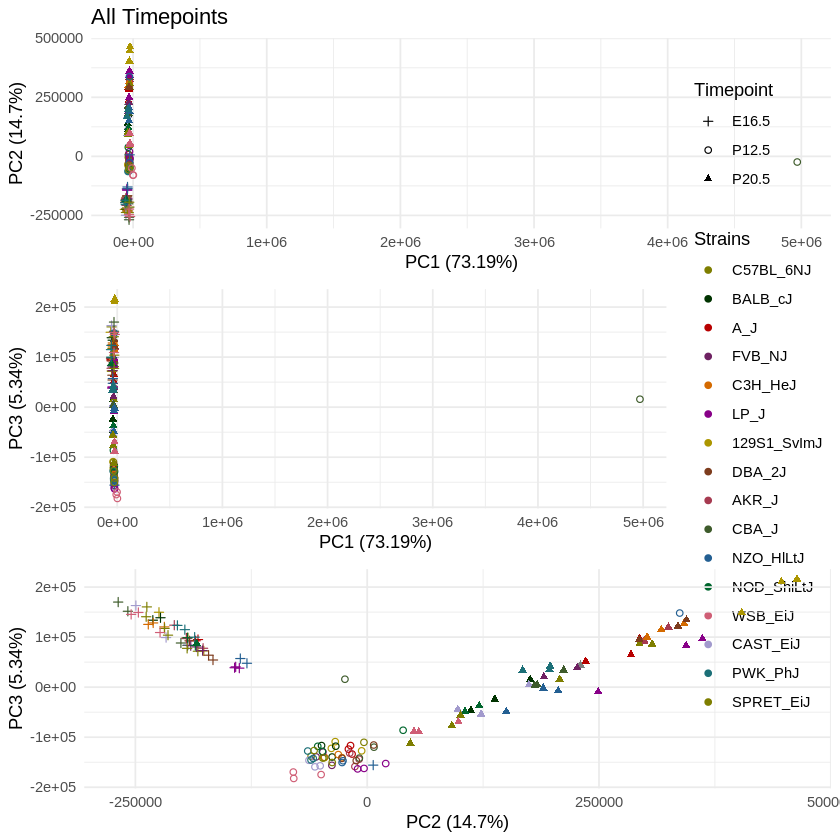

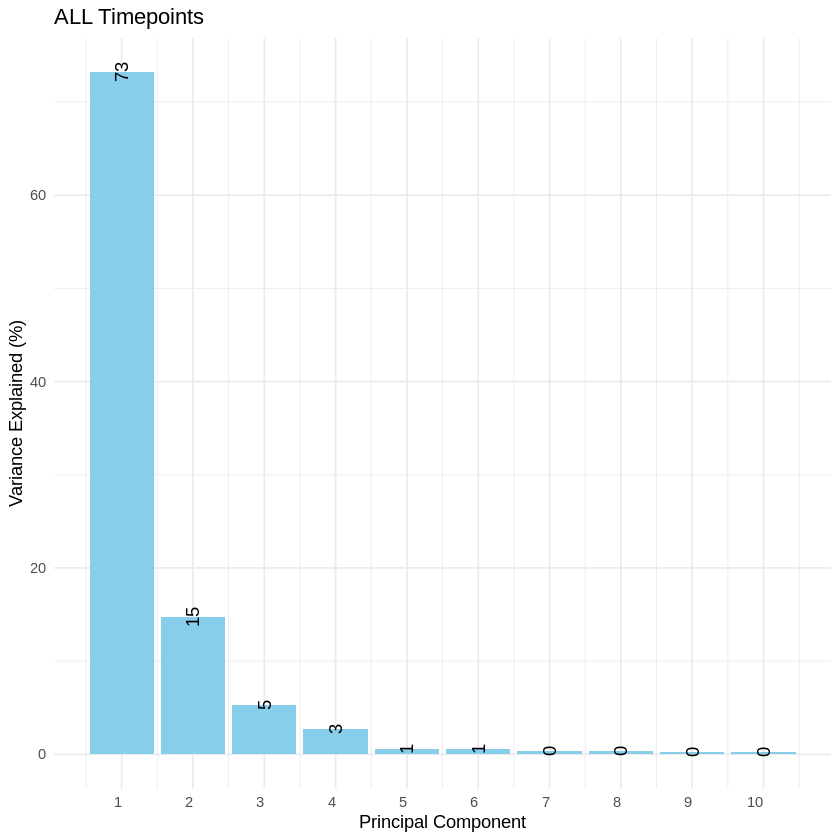

In [37]:


custom_colors <- c(
  '#7E7E00',
  '#003300',
  '#B80000',
  '#6E2162',
  '#D46A00',
  '#880088',
  '#AC9600',
  '#7D3C1D',
  '#A63A50',
  '#3E5B2B',
  '#235F92',
  '#00662D',
  '#CF5E75',
  '#A29ACD',
   '#1B6F77',
  '#7E7E00',
  '#1F4788'
)

samplenames_order = c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J','NZO_HlLtJ',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')



# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 





# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("All_timepoints_edgeR_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 , angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "ALL Timepoints",
       x = "Principal Component", y = "Variance Explained (%)") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +  # Set custom x-axis breaks
  theme(axis.text.x = element_text(angle = 0, hjust = 1))  # Rotate and allow overlap


# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("ALL_timepoints_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

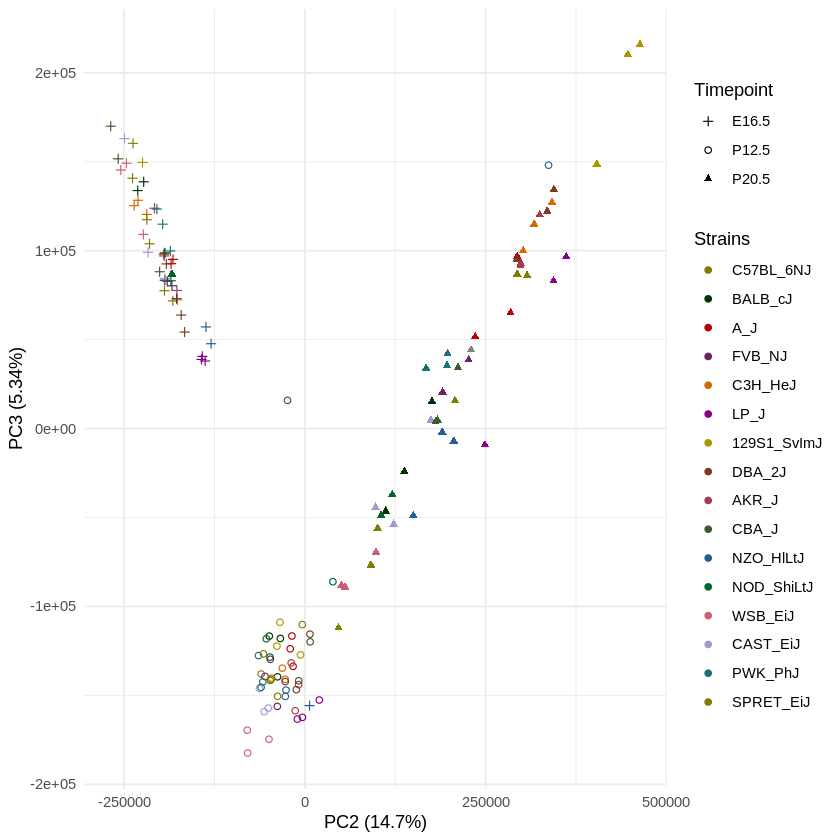

In [38]:
pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") + labs(color = "Strains") 
  pca_plot_pc2_pc3

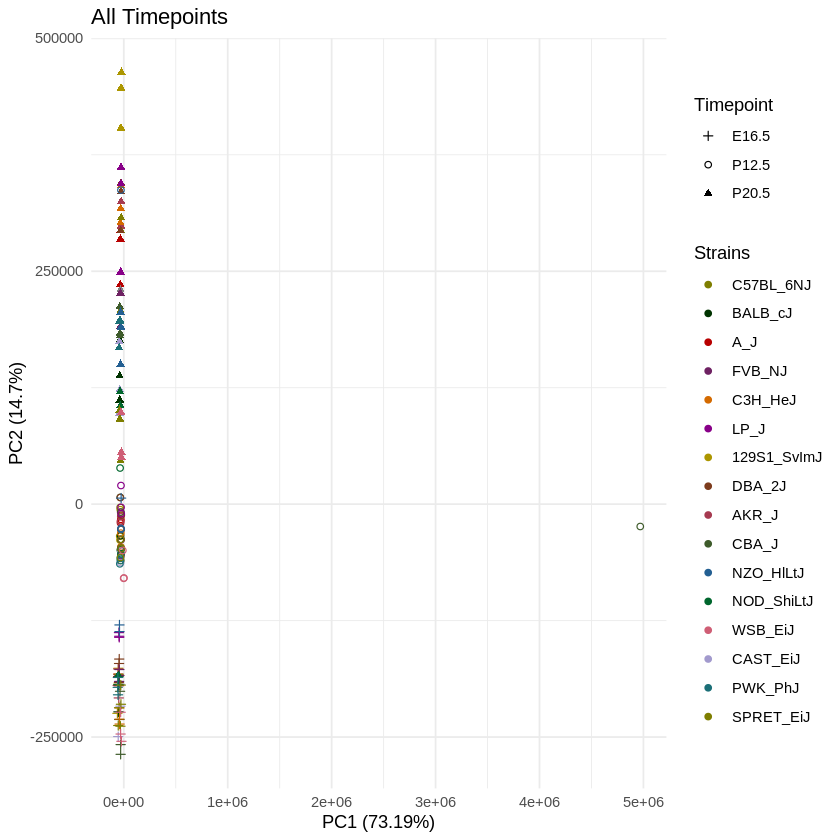

In [39]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 
pca_plot_pc1_pc2

In [40]:

#https://sdgamboa.github.io/post/2020_volcano/

pairwise_combinations <- list(
  c( 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('WSB_EiJ-P12.5', 'PWK_PhJ-P12.5')
  # Add more contrasts here if needed
)


library(edgeR)
library(EnhancedVolcano)
library(foreach)
library(doParallel)


# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}
# Combine results from all comparisons
all_results <- data.frame()

# Number of cores for parallel processing
num_cores <- 18  # Change this to the desired number of cores

# Set up parallel backend
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Parallelized loop to create and save volcano plots
foreach(pair = pairwise_combinations) %dopar% {
  library(edgeR)
  library(EnhancedVolcano)
    # Load packages
  library(tidyverse)
  library(ggrepel)
  library(kableExtra)
  condition1 <- pair[1]
  condition2 <- pair[2]
  # Subset the data for the specific conditions
  #pair <- c('CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5')
  sub_lables <- paste(pair, c(".1", ".1", ".2",".2", ".3", ".3"), sep = "")
  sub_samples <- sub("\\.\\d$", "", sub_lables) 
  subset_data <-rawdata_copy$counts[,sub_lables]
  dge <- DGEList(counts = subset_data, group = factor(sub_samples))
  keep <- filterByExpr(y = dge)
  dge <- dge[keep, , keep.lib.sizes=FALSE]
  dge <- calcNormFactors(object = dge, method = "TMM")
  dge <- estimateDisp(y = dge)
  et <- exactTest(object = dge)
  top_degs = topTags(object = et, n = "Inf")
  
  data <- data.frame(Genes = rownames(top_degs$table),
                    logFC = top_degs$table$logFC,
                     FDR = top_degs$table$FDR,
                     PValue = top_degs$table$PValue)

  data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.05 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.05 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )

    data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.001 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.001 ~ "FDR 0.001", 
          TRUE ~ "Unchanged")
      )

    

    data %>% 
      count(Expression, Significance) 

    top <- 30 # number of to genes 
    top_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top)
    )
    all_top <- 1000
    all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC)))%>% 
        head(all_top) ,
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(all_top)
    )


    comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
    all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = top_genes$Expression,
                                                Significance = top_genes$Significance,
                                                Genes = top_genes$Genes))

    p2 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Expression), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
      guides(colour = guide_legend(override.aes = list(size=1.5)))  + theme_minimal()
    p2 <-  p2 +
      geom_label_repel(data = top_genes,
                      mapping = aes(logFC, -log(FDR,10), label = Genes),
                      size = 2) + ggtitle(paste( condition1, "_vs_", condition2, sep = ""))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_P12.5_up_down_volcano_plot.pdf", sep = ""), width = 6, height = 8)  # Adjust width and height as needed
    print(p2)
    dev.off()  # Close the PDF device

  
    p3 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Significance), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_viridis_d() +
      guides(colour = guide_legend(override.aes = list(size=1.5))) +theme_minimal()
    p3 <-  p3 +
      geom_label_repel(data = top_genes,
                      mapping = aes(logFC, -log(FDR,10), label = Genes),
                      size = 2) + ggtitle(paste( condition1, "_vs_", condition2, sep = ""))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_P12.5_singnificant_volcano_plot.pdf", sep = ""), width = 6, height = 8)  # Adjust width and height as needed
    print(p3)
    dev.off() 



}

all_results
# Stop the parallel backend
stopCluster(cl)


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel



[[1]]
null device 
          1 

[[2]]
null device 
          1 

[[3]]
null device 
          1 

[[4]]
null device 
          1 

[[5]]
null device 
          1 

[[6]]
null device 
          1 

[[7]]
null device 
          1 

[[8]]
null device 
          1 

[[9]]
null device 
          1 

[[10]]
null device 
          1 

[[11]]
null device 
          1 

[[12]]
null device 
          1 

[[13]]
null device 
          1 

[[14]]
null device 
          1 

[[15]]
null device 
          1 

[[16]]
null device 
          1 

[[17]]
null device 
          1 

[[18]]
null device 
          1

<0 x 0 matrix>

In [41]:
pairwise_combinations <- list(
  c( 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('WSB_EiJ-P12.5', 'PWK_PhJ-P12.5')
  # Add more contrasts here if needed
)

library(edgeR)
library(EnhancedVolcano)
library(tidyverse)
library(ggrepel)
library(kableExtra)

# Combine results from all comparisons
all_results <- data.frame()

# Loop through pairwise combinations
for (pair in pairwise_combinations) {
  condition1 <- pair[1]
  condition2 <- pair[2]
  
  # Subset the data for the specific conditions
  sub_labels <- paste(pair, c(".1", ".1", ".2",".2", ".3", ".3"), sep = "")
  sub_samples <- sub("\\.\\d$", "", sub_labels)
  subset_data <- rawdata_copy$counts[, sub_labels]
  
  dge <- DGEList(counts = subset_data, group = factor(sub_samples))
  keep <- filterByExpr(y = dge)
  dge <- dge[keep, , keep.lib.sizes = FALSE]
  dge <- calcNormFactors(object = dge, method = "TMM")
  dge <- estimateDisp(y = dge)
  et <- exactTest(object = dge)
  top_degs <- topTags(object = et, n = "Inf")
  
  data <- data.frame(Genes = rownames(top_degs$table),
                     logFC = top_degs$table$logFC,
                     FDR = top_degs$table$FDR,
                     PValue = top_degs$table$PValue)


  
  data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.05 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.05 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )

    data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.001 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.001 ~ "FDR 0.001", 
          TRUE ~ "Unchanged")
      )

    
  
  data %>% 
      count(Expression, Significance) 

    top <- 30 # number of to genes 
    top_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) %>% 
        head(top)
    )
    all_top <- 1000
    all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) ,
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) 
    )

    comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
    all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = all_genes$Expression,
                                                Significance = all_genes$Significance,
                                                Genes = all_genes$Genes))

}

# Print or use all_results as needed
print(all_results)



Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows


Using classic mode.



ERROR: Error in count(., Expression, Significance): Argument 'x' is not a vector: list


In [ ]:
all_results

Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Olfr1033
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Gm20594
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Fam221b
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Nphs1
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Axdnd1
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Pde6a
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Rab44
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,H2-Q10
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Cntnap5b


In [ ]:
# Combine top_genes data from all comparisons
combined_top_genes <-  all_results
combined_top_genes



Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Olfr1033
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Gm20594
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Fam221b
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Nphs1
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Axdnd1
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Pde6a
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Rab44
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,H2-Q10
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,Up-regulated,FDR 0.001,Cntnap5b


In [ ]:
library(ggplot2)

# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)

# Create the side-by-side bar plot with labels
bar_plot <- ggplot(summary_data, aes(x = Comparison)) +
  geom_bar(aes(y = `Up-regulated`, fill = "Up-regulated"), 'dodge', stat = "identity", width = 1) +
  geom_bar(aes(y = `Down-regulated`, fill = "Down-regulated"), position = 'dodge', stat = "identity", width = 0.5) +
  scale_fill_manual(values = c("Up-regulated" = "blue", "Down-regulated" = "red")) +
  xlab("Comparison") +
  ylab("Count") +
  ggtitle("Count of Up-regulated and Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`), vjust = -0.3, size = 3, color = "black") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`), vjust = 1, size = 3, color = "black")

# Print the side-by-side bar plot
print(bar_plot)




ERROR: [1m[33mError[39m in `fortify()`:[22m
[1m[22m[33m![39m `data` must be a [34m<data.frame>[39m, or an object coercible by `fortify()`,
  not the string "dodge".


Comparison,Down-regulated,Up-regulated
<chr>,<dbl>,<dbl>
C57BL_6NJ-P12.5_vs_129S1_SvImJ-P12.5,691,691
C57BL_6NJ-P12.5_vs_A_J-P12.5,527,607
C57BL_6NJ-P12.5_vs_AKR_J-P12.5,771,737
C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5,603,553
C57BL_6NJ-P12.5_vs_C3H_HeJ-P12.5,727,653
C57BL_6NJ-P12.5_vs_CAST_EiJ-P12.5,1913,1836
C57BL_6NJ-P12.5_vs_CBA_J-P12.5,822,572
C57BL_6NJ-P12.5_vs_DBA_2J-P12.5,690,723
C57BL_6NJ-P12.5_vs_FVB_NJ-P12.5,655,987


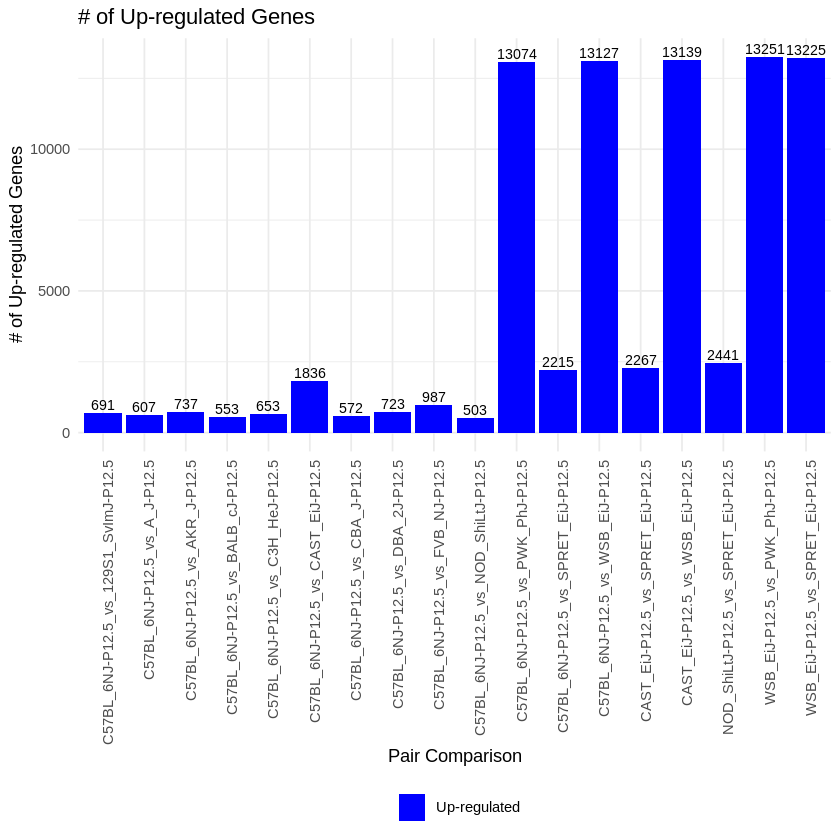

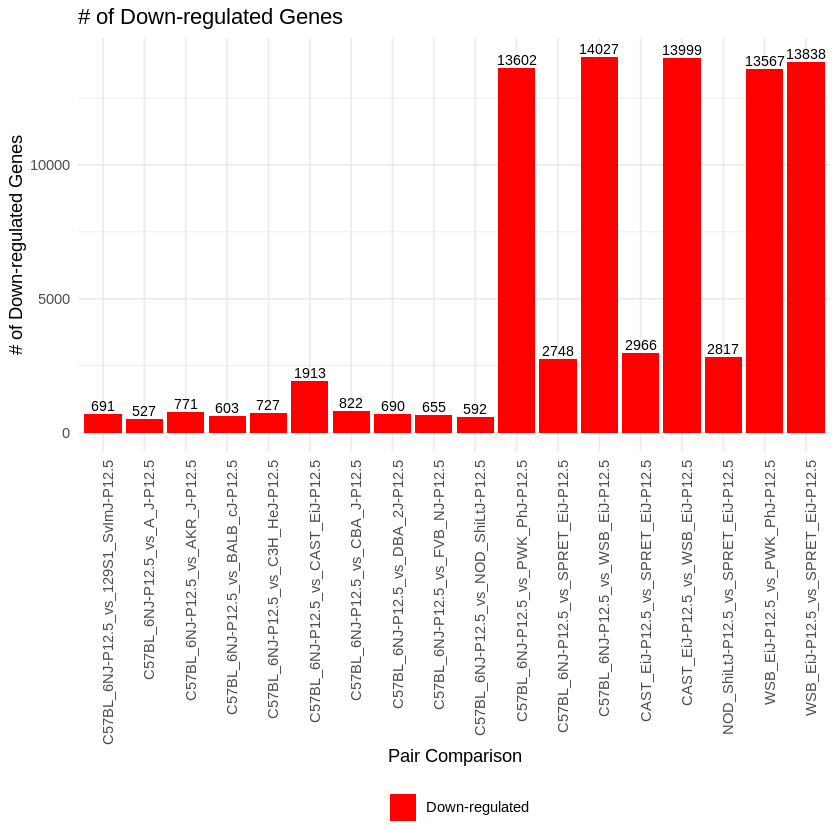

In [ ]:
library(ggplot2)

# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)
summary_data
# Create separate plots for upregulated and downregulated genes
upregulated_plot <- ggplot(summary_data, aes(x = Comparison, y = `Up-regulated`, fill = "Up-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Up-regulated" = "blue")) +
  xlab("Pair Comparison") +
  ylab("# of Up-regulated Genes") +
  ggtitle("# of Up-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom")+
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`), vjust = -0.3, size = 3, color = "black") 

downregulated_plot <- ggplot(summary_data, aes(x = Comparison, y = `Down-regulated`, fill = "Down-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Down-regulated" = "red")) +
  xlab("Pair Comparison") +
  ylab("# of Down-regulated Genes") +
  ggtitle("# of Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`), vjust = -0.3, size = 3, color = "black")

# Print the separate plots
print(upregulated_plot)
print(downregulated_plot)


In [ ]:
unique(combined_top_genes$Comparison)

[1] "C57BL_6NJ-P12.5_vs_BALB_cJ-P12.5"    
 [2] "C57BL_6NJ-P12.5_vs_A_J-P12.5"        
 [3] "C57BL_6NJ-P12.5_vs_FVB_NJ-P12.5"     
 [4] "C57BL_6NJ-P12.5_vs_C3H_HeJ-P12.5"    
 [5] "C57BL_6NJ-P12.5_vs_129S1_SvImJ-P12.5"
 [6] "C57BL_6NJ-P12.5_vs_DBA_2J-P12.5"     
 [7] "C57BL_6NJ-P12.5_vs_AKR_J-P12.5"      
 [8] "C57BL_6NJ-P12.5_vs_CBA_J-P12.5"      
 [9] "C57BL_6NJ-P12.5_vs_NOD_ShiLtJ-P12.5" 
[10] "C57BL_6NJ-P12.5_vs_WSB_EiJ-P12.5"    
[11] "C57BL_6NJ-P12.5_vs_CAST_EiJ-P12.5"   
[12] "C57BL_6NJ-P12.5_vs_PWK_PhJ-P12.5"    
[13] "C57BL_6NJ-P12.5_vs_SPRET_EiJ-P12.5"  
[14] "CAST_EiJ-P12.5_vs_SPRET_EiJ-P12.5"   
[15] "WSB_EiJ-P12.5_vs_SPRET_EiJ-P12.5"    
[16] "CAST_EiJ-P12.5_vs_WSB_EiJ-P12.5"     
[17] "NOD_ShiLtJ-P12.5_vs_SPRET_EiJ-P12.5" 
[18] "WSB_EiJ-P12.5_vs_PWK_PhJ-P12.5"

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_upregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)

# Open a PDF device to save the plot
pdf("P12.5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = c('WSB_EiJ-P12.5_vs_PWK_PhJ-P12.5', 'C57BL_6NJ-P12.5_vs_CAST_EiJ-P12.5', 'C57BL_6NJ-P12.5_vs_SPRET_EiJ-P12.5', 'CAST_EiJ-P12.5_vs_WSB_EiJ-P12.5',
 'WSB_EiJ-P12.5_vs_SPRET_EiJ-P12.5', 'C57BL_6NJ-P12.5_vs_WSB_EiJ-P12.5','C57BL_6NJ-P12.5_vs_PWK_PhJ-P12.5') , order.by = c("degree", "freq"),nsets = 7,point.size = 3.5, line.size = 2, 
    mainbar.y.label = "Genes Intersections (Up-regulated)", sets.x.label = "Pair Comaprision",cutoff = 7) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


png 
  2

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_downregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_downregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)

# Open a PDF device to save the plot
pdf("P12.5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = c('WSB_EiJ-P12.5_vs_PWK_PhJ-P12.5', 'C57BL_6NJ-P12.5_vs_CAST_EiJ-P12.5', 'C57BL_6NJ-P12.5_vs_SPRET_EiJ-P12.5', 'CAST_EiJ-P12.5_vs_WSB_EiJ-P12.5',
 'WSB_EiJ-P12.5_vs_SPRET_EiJ-P12.5', 'C57BL_6NJ-P12.5_vs_WSB_EiJ-P12.5','C57BL_6NJ-P12.5_vs_PWK_PhJ-P12.5') , order.by = c("degree", "freq"),nsets = 7,point.size = 3.5, line.size = 2, 
    mainbar.y.label = "Genes Intersections (Down-regulated)", sets.x.label = "Pair Comaprision",cutoff = 7) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()

png 
  2

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
pairwise_combinations <- list(
  c( 'C57BL_6NJ-P12.5', 'BALB_cJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'A_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'FVB_NJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'C3H_HeJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', '129S1_SvImJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'DBA_2J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'AKR_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CBA_J-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'NOD_ShiLtJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'CAST_EiJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'PWK_PhJ-P12.5'),
  c( 'C57BL_6NJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'WSB_EiJ-P12.5', 'SPRET_EiJ-P12.5'),
  c( 'CAST_EiJ-P12.5', 'WSB_EiJ-P12.5'),
  c( 'NOD_ShiLtJ-P12.5', 'SPRET_EiJ-P12.5'),
  c('WSB_EiJ-P12.5', 'PWK_PhJ-P12.5')
  # Add more contrasts here if needed
)



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Up-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation








In [ ]:
library(foreach)
library(doParallel)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Combine the results from all pairwise combinations
all_enrichment_results <- do.call("rbind", go_enrichment_list)

# Create bar plots in parallel
foreach(i = 1:length(pairwise_combinations), .packages = c("ggplot2")) %dopar% {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  comparison_results <- all_enrichment_results[all_enrichment_results$Description == comparison_name, ]

  # Sort the results by adjusted p-value
  sorted_results <- comparison_results[order(comparison_results$p.adjust), ]

  # Plot the top enriched terms (let's say top 20)
  top_terms <- sorted_results[1:20, ]
  
  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = reorder(Term, -Count), y = Count)) +
    geom_bar(stat = "identity", fill = "skyblue") +
    labs(title = comparison_name,
         x = "Enriched Terms",
         y = "Gene Count") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1))
  
  # Save the plot
  filename <- paste0("go-ontology-plots/",comparison_name, "_barplot.png")
  ggsave(filename, plot = p)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

